 # Question 1: Wage discrimination in starting salaries
 Does wage discrimination exist in the starting salaries of faculty members (i.e., salaries in the year hired)?

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import scipy.stats as stats
import scipy.stats as ttest_ind
import warnings
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None
salaries = pd.read_csv("salary.txt", sep=r"\s+")

In [2]:
#Filtering out starting salaries 
starting_salaries = salaries[salaries["year"] == salaries["startyr"]].copy()

[]

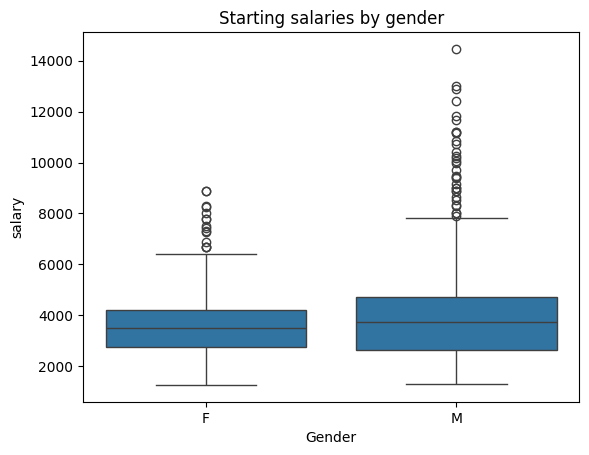

In [3]:
# Generally plotting salaries for each sex to see if there is an observable difference.
sns.boxplot(data = starting_salaries, x = "sex", y ="salary")
plt.xlabel("Gender")
plt.title ("Starting salaries by gender")
plt.plot()

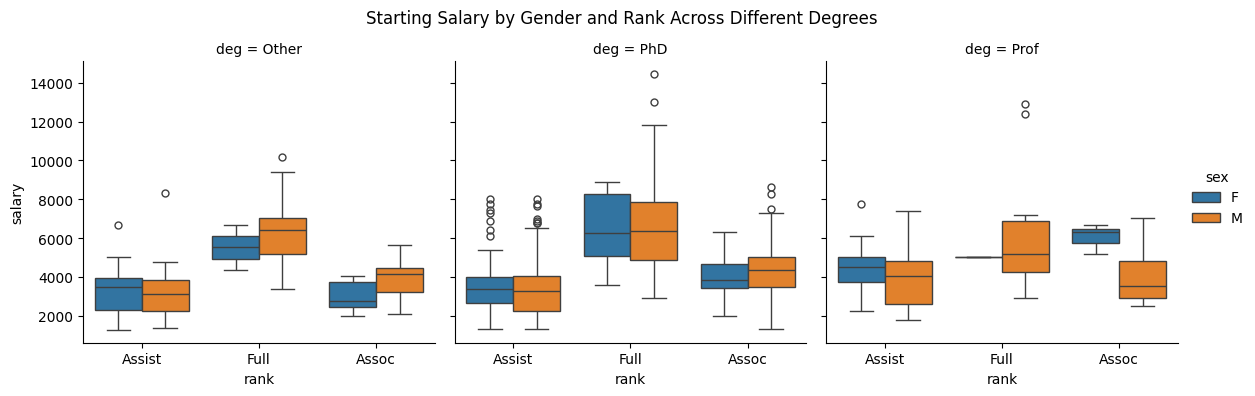

In [4]:
#Now doing some data exploration to observe for any patterns in the data before we start using numerical methos.
g = sns.catplot(
    data=starting_salaries,
    x="rank",
    y="salary",
    col="deg",
    hue="sex",
    kind="box",
    height=4,
    aspect=1
)

g.fig.suptitle("Starting Salary by Gender and Rank Across Different Degrees")

g.fig.subplots_adjust(top=0.85)  # pushes plots down

plt.show()

Now since generally one's years since their highest degree which can also be years they might have been in the industry might affect their starting salary, we can create a new field called "years_since_degree" to see if there is any observable pattern between experience and starting salary
This field is to help observe any patterns between time spent before being hired, starting salary, and sex.

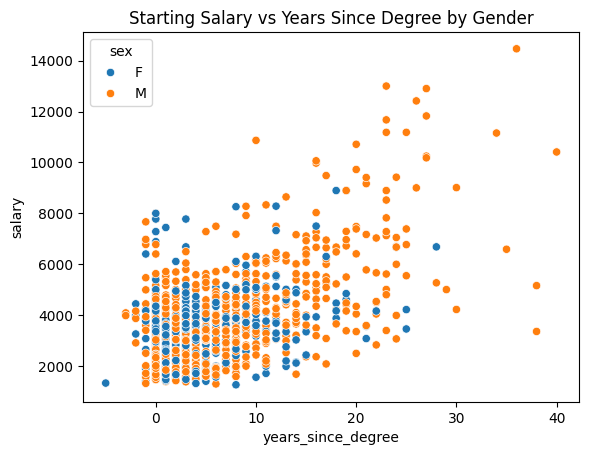

In [5]:
starting_salaries["years_since_degree"] = starting_salaries["startyr"] - starting_salaries["yrdeg"]
sns.scatterplot(data = starting_salaries, x = "years_since_degree", y = "salary", hue = "sex")
plt.title("Starting Salary vs Years Since Degree by Gender")  # <-- set title here
plt.show()

## 2. Numerical summaries

In [ ]:
# Getting numeric summary statistics for salaries by sex
starting_salary_summary = starting_salaries.groupby("sex").agg(
    median_salary=("salary", "median"),
    mean_salary=("salary", "mean"),
    count=("salary", "count")
).reset_index() 
print (starting_salary_summary)

starting_salary_melted = starting_salary_summary.melt(
    id_vars='sex', 
    value_vars=['median_salary', 'mean_salary'], 
    var_name='statistic', 
    value_name='salary'
)

sns.barplot(data=starting_salary_melted, x='sex', y='salary', hue='statistic', palette=['green','red'])
plt.title("Mean and Median Starting Salary by Gender")
plt.ylabel("Salary")
plt.xlabel("Gender")
plt.show()

Checking for correlation between gender and starting salary.

In [6]:
starting_salaries['sex_numeric'] = starting_salaries['sex'].map({'F': 0, 'M': 1}) 
correlation = starting_salaries['salary'].corr(starting_salaries['sex_numeric']) 
print("Correlation between starting salary and gender:", correlation)


Correlation between starting salary and gender: 0.10901192566702962


After checking for correlation between gender and starting salary, we observe that there is a very weak positive of 0.1 association between gender and starting salary, with males earning more on average.

## 3. Statistical Methods

Now that we have an idea of the data, we can start statistically assessing the data.

First we will use a multiple linear regression model predicting salary from sex, field, degree, experience, rank, and admin.

In [128]:
model = smf.ols(
    "salary ~ sex + field + deg + years_since_degree + rank + admin",
    data=starting_salaries
).fit()

# 1. Map to Human-Readable Labels for the Executive Report
name_map_start = {
    'Intercept': 'Baseline Constant',
    'sex[T.M]': 'Sex: Male (Ref: Female)',
    'field[T.Other]': 'Field: Other',
    'field[T.Prof]': 'Field: Professional',
    'deg[T.PhD]': 'Degree: PhD',
    'deg[T.Prof]': 'Degree: Professional',
    'rank[T.Assoc]': 'Rank: Associate Professor',
    'rank[T.Full]': 'Rank: Full Professor',
    'years_since_degree': 'Years Since Degree',
    'admin': 'Administrative Duties'
}

# 2. Extract results and map names
results_start = pd.DataFrame({
    'Variable': model.model.exog_names,
    'Coefficient': model.params.values,
    'Std. Error': model.bse.values,
    'P-Value': model.pvalues.values
})
results_start['Variable'] = results_start['Variable'].map(name_map_start).fillna(results_start['Variable'])

# 3. Sort by P-Value (Ascending)
results_start_sorted = results_start.sort_values(by="P-Value", ascending=True)

# 4. Generate Styled HTML
styled_start_table = (results_start_sorted.style
    .format({
        'Coefficient': '${:,.2f}',
        'Std. Error': '{:.2f}',
        'P-Value': '{:.4f}'
    })
    # Apply light red/pink highlighting to the 'Sex: Male' row specifically if it's significant
    .apply(lambda x: ['background-color: #f8d7da' if 'Sex: Male' in str(x['Variable']) and x['P-Value'] < 0.05 else '' for _ in x], axis=1)
    # Apply light green to all other significant rows
    .apply(lambda x: ['background-color: #e6ffed' if 'Sex: Male' not in str(x['Variable']) and x['P-Value'] < 0.05 else '' for _ in x], axis=1)
    .set_caption("<b>Table 1: Regression Analysis of Starting Salary Determinants (Sorted by Significance)</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#343a40'), ('color', 'white'), ('font-weight', 'bold'), ('border', '1px solid #ccc')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.25em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)
start_diagnostics = pd.DataFrame({
    "Metric": [
        "R-Squared (Explanatory Power)", 
        "Adjusted R-Squared", 
        "F-Statistic (Overall Significance)", 
        "Number of Observations",
        "Log-Likelihood"
    ],
    "Value": [
        f"{model.rsquared:.4f}", 
        f"{model.rsquared_adj:.4f}", 
        f"{model.f_pvalue:.4e}", 
        f"{int(model.nobs):,}",
        f"{model.llf:,.2f}"
    ]
})
# Style the Diagnostics Table to match Table 1
styled_start_diag = (start_diagnostics.style
    .set_caption("<b>Table 1b: Model Fit Diagnostics for Starting Salaries</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#495057'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.1em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)

display(styled_start_table)
display(styled_start_diag)

Variable,Coefficient,Std. Error,P-Value
Baseline Constant,"$2,378.99",175.75,0.0000
Rank: Full Professor,"$2,134.69",199.80,0.0000
Years Since Degree,$70.37,9.45,0.0000
Field: Professional,$859.93,156.18,0.0000
Field: Other,$469.38,131.68,0.0004
Rank: Associate Professor,$389.62,132.50,0.0033
Degree: PhD,$385.28,155.14,0.0132
Degree: Professional,$508.41,222.32,0.0224
Sex: Male (Ref: Female),$-147.11,94.01,0.1179
Administrative Duties,$31.11,225.96,0.8905


Metric,Value
R-Squared (Explanatory Power),0.3875
Adjusted R-Squared,0.3824
F-Statistic (Overall Significance),2.1450e-110
Number of Observations,"1,107"
Log-Likelihood,"-9,582.47"


From the above we observe that statistically significant predictors are Statistically significant predictors are rank, experience, and field.

Next we use ANOVA to also test whether removing sex would affect the model.

In [129]:
# Test removing gender
model_full = smf.ols(
    "salary ~ sex + field + deg + years_since_degree + rank + admin",
    data=starting_salaries
).fit()

model_reduced_gender = smf.ols(
    "salary ~ field + deg + years_since_degree + rank + admin",
    data=starting_salaries
).fit()

anova_results = anova_lm(model_reduced_gender, model_full)

# 2. Format the results for a professional table
# We pull the specific row comparing the two models
anova_df = pd.DataFrame({
    "Comparison": ["Model without Gender vs. Full Model"],
    "Sum of Squares Diff": [anova_results.loc[1, 'ss_diff']],
    "DF Diff": [int(anova_results.loc[1, 'df_diff'])],
    "F-Statistic": [anova_results.loc[1, 'F']],
    "P-Value": [anova_results.loc[1, 'Pr(>F)']]
})

# 3. Styled HTML Output
styled_anova = (anova_df.style
    .format({
        'Sum of Squares Diff': '{:,.2f}',
        'F-Statistic': '{:.4f}',
        'P-Value': '{:.4f}'
    })
    .set_caption("<b>Table 1c: ANOVA F-Test - Impact of Gender on Starting Salaries</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'caption', 'props': [('font-size', '1.1em'), ('font-weight', 'bold'), ('margin-bottom', '10px')]}
    ])
    .hide(axis='index')
    # Apply highlight if significant
    .apply(lambda x: ['background-color: #e6ffed' if x['P-Value'] < 0.05 else 'background-color: #f8d7da' for _ in x], axis=1)
)

styled_anova

Comparison,Sum of Squares Diff,DF Diff,F-Statistic,P-Value
Model without Gender vs. Full Model,"4,777,296.66",1,2.4490,0.1179


From the above we observe a p value of 0.118 which means that removing gender would not significantly affect starting salaries, if we assume an non interactive model.

Next we will create an interactive model to see if there are any interactions between the predictors and gender.

This can help us observe if their are any interaction with gender that might point to starting salary discrimation by gender.

In [130]:
#Interactive model

model2 = smf.ols(
    "salary ~ sex * (field + deg + years_since_degree + rank)",
    data=starting_salaries
).fit()

# Extracting coefficients table
results_df = pd.DataFrame({
    "coef": model2.params,
    "p_value": model2.pvalues,
    "t_value": model2.tvalues
})

# Sorting by p-value ascending to see if there is any sex interaction that is significant
results_df_sorted = results_df.sort_values(by="p_value", ascending=True)

# 1. Map to Human-Readable Labels
name_map = {
    'Intercept': 'Baseline Constant',
    'C(sex)[T.M]': 'Sex: Male (Ref: Female)',
    'C(field)[T.Other]': 'Field: Other',
    'C(field)[T.Prof]': 'Field: Professional',
    'C(deg)[T.PhD]': 'Degree: PhD',
    'C(deg)[T.Prof]': 'Degree: Professional',
    'yrdeg': 'Year of Degree',
    'admin': 'Administrative Duties',
    'years_since_degree': 'Years Since Degree',
    'years_at_inst': 'Years at Institution'
}

# 2. Prepare the DataFrame for the HTML view
# Resetting index turns the variable names into a styleable column
results_final = results_df.copy().reset_index()
results_final.rename(columns={'index': 'Variable'}, inplace=True)
results_final['Variable'] = results_final['Variable'].map(name_map).fillna(results_final['Variable'])

# 3. Sort by p_value (Ascending)
results_final = results_final.sort_values(by="p_value", ascending=True)

# 4. Generate Styled HTML
styled_table = (results_final.style
    .format({
        'coef': '{:.4f}',
        'p_value': '{:.4f}',
        't_value': '{:.2f}'
    })
    # Apply light green highlighting to significant rows (p < 0.05)
    .apply(lambda x: ['background-color: #e6ffed' if x['p_value'] < 0.05 else '' for _ in x], axis=1)
    # Add a bold border to separate the Variable names
    .set_properties(subset=['Variable'], **{'font-weight': 'bold', 'border-right': '1px solid #ccc'})
    .set_caption("<b>Table 2: Significant Predictors of Promotion Salary Increase (Sorted by P-Value)</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f8f9fa'), ('color', '#333'), ('border', '1px solid #ccc'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.25em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)
# Create the Diagnostic DataFrame for the Interaction Model
interaction_diagnostics = pd.DataFrame({
    "Metric": [
        "R-Squared (Explanatory Power)", 
        "Adjusted R-Squared", 
        "F-Statistic P-Value", 
        "Number of Observations",
        "AIC (Akaike Information Criterion)"
    ],
    "Value": [
        f"{model2.rsquared:.4f}", 
        f"{model2.rsquared_adj:.4f}", 
        f"{model2.f_pvalue:.4e}", 
        f"{int(model2.nobs):,}",
        f"{model2.aic:,.2f}"
    ]
})
styled_interaction_diag = (interaction_diagnostics.style
    .set_caption("<b>Table 2b: Interaction Model Fit Diagnostics</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#495057'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.1em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)

display(styled_table)
display(styled_interaction_diag)

Variable,coef,p_value,t_value
Baseline Constant,2767.7577,0.0000,10.54
rank[T.Full],2514.0800,0.0000,5.99
field[T.Prof],1059.4832,0.0004,3.54
sex[T.M]:years_since_degree,73.5542,0.0005,3.49
deg[T.Prof],1060.8552,0.0095,2.60
field[T.Other],403.5185,0.0359,2.10
sex[T.M],-679.9913,0.0517,-1.95
rank[T.Assoc],449.4094,0.0911,1.69
sex[T.M]:deg[T.Prof],-748.2440,0.1276,-1.52
sex[T.M]:rank[T.Full],-623.1070,0.1880,-1.32


Metric,Value
R-Squared (Explanatory Power),0.3983
Adjusted R-Squared,0.3900
F-Statistic P-Value,3.9030e-109
Number of Observations,"1,107"
AIC (Akaike Information Criterion),"19,177.15"


We then observe that is only significant when there is experience (5.070323e-04) 

We then observe that there is relevance gender almost insignificant with p value of 0.0517 but close eniugh to be considerable.

Therefore we will analyse using permutations to see if we randomly assign gender, whether we observe that it is by chance that the observed differences in starting salary are by chance. 

The null hypothesis we will be testing for, is that there is no difference between males and females starting salaries

In [11]:
#Observed difference in means (M - F)
obs_diff = (
    starting_salaries[starting_salaries["sex"] == "M"]["salary"].mean()
    - starting_salaries[starting_salaries["sex"] == "F"]["salary"].mean()
)

print(obs_diff)

415.22248665226107


In [12]:
# Permutation test
np.random.seed(123)

perm_diffs = []

for _ in range(5000):
    shuffled_sex = np.random.permutation(starting_salaries["sex"])
    
    diff = (
        starting_salaries["salary"][shuffled_sex == "M"].mean()
        - starting_salaries["salary"][shuffled_sex == "F"].mean()
    )
    
    perm_diffs.append(diff)

perm_diffs = np.array(perm_diffs)

p_value = np.mean(np.abs(perm_diffs) >= abs(obs_diff))
p_value

np.float64(0.0004)

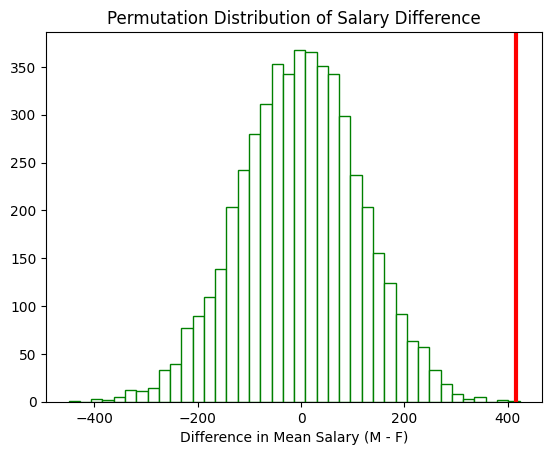

In [13]:
# Histogram of permutation distribution
plt.hist(perm_diffs, bins=40, color='white', edgecolor='green')
plt.axvline(obs_diff, linewidth=3, color='red')
plt.title("Permutation Distribution of Salary Difference")
plt.xlabel("Difference in Mean Salary (M - F)")
plt.show()

From this we can conclude that the average salary difference of $415 between males and females is extremely unlikely

Given that our null hypothesis in the permutation test is that there is no difference between males and females starting salaries, but our p value < 0.05 we reject the null hypothesis

Therefore, the observed difference is extremely unlikely to happen by chance if gender had no effect.

Now lets check whether the unexplained salary differences (residuals)still differ between males and females after controlling for rank, field, degree, year of degree, and admin

In [14]:
from scipy.stats import ttest_ind

lm_base = smf.ols(
    "salary ~ rank + field + deg + yrdeg + admin + years_since_degree",
    data=starting_salaries
).fit()

residuals = lm_base.resid
residuals_f = residuals[starting_salaries["sex"] == "F"]
residuals_m = residuals[starting_salaries["sex"] == "M"]

# Welch's t-test (unequal variance)
result_residuals = ttest_ind(residuals_m, residuals_f, equal_var=False)

print(f"T-statistic: {result_residuals.statistic:.3f}")
print(f"P-value: {result_residuals.pvalue:.6f}")

T-statistic: 3.208
P-value: 0.001383


### Gender by Rank

In [15]:
#Select assistant professors in their first year
assist_prof_subset = starting_salaries[
    (starting_salaries["rank"] == "Assist") &
    (starting_salaries["startyr"] == starting_salaries["year"])
].copy()

In [16]:
#convert columns so they can go into the regression model
categorical_cols = ["admin", "sex", "field", "deg"]
for col in categorical_cols:
    assist_prof_subset[col] = assist_prof_subset[col].astype("category")

In [131]:
#Assist prof model (dropped admin bc only 1 point was admin == 1)
assist_lm = smf.ols(
    "salary ~ sex + field + deg + yrdeg + year",
    data=assist_prof_subset
).fit()

# 1. Extract results from the Assistant Professor OLS model
assist_results = pd.DataFrame({
    'Variable': assist_lm.model.exog_names,
    'Coefficient': assist_lm.params.values,
    'Std. Error': assist_lm.bse.values,
    't-statistic': assist_lm.tvalues.values,
    'P-Value': assist_lm.pvalues.values
})

# 2. Map to Human-Readable Names for administrators
name_map_assist = {
    'Intercept': 'Baseline Constant',
    'sex[T.M]': 'Sex: Male (Ref: Female)',
    'field[T.Other]': 'Field: Other (Ref: Arts)',
    'field[T.Prof]': 'Field: Professional',
    'deg[T.PhD]': 'Degree: PhD',
    'deg[T.Prof]': 'Degree: Professional',
    'yrdeg': 'Years Since Degree',
    'year': 'Year of Data Entry'
}
assist_results['Variable'] = assist_results['Variable'].map(name_map_assist)

# 3. Create the Styled HTML Table
styled_assist_table = (assist_results.style
    .format({
        'Coefficient': '${:,.2f}',
        'Std. Error': '{:.2f}',
        't-statistic': '{:.2f}',
        'P-Value': '{:.4f}'
    })
    # Highlight the Sex row to draw the administrator's eye
    .apply(lambda x: ['background-color: #f8d7da' if 'Sex: Male' in str(v) else '' for v in x], axis=1)
    .set_caption("Table 3: Analysis of Starting Salaries for Assistant Professors")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#343a40'), ('color', 'white'), ('font-family', 'Arial')]},
        {'selector': 'td', 'props': [('border', '1px solid #dee2e6'), ('padding', '8px')]}
    ])
    .hide(axis='index')
)
# Create the Diagnostic DataFrame for Assistant Professors
assist_diagnostics = pd.DataFrame({
    "Metric": [
        "R-Squared (Explanatory Power)", 
        "Adjusted R-Squared", 
        "F-Statistic P-Value", 
        "Observations (Assistant Profs)",
        "Log-Likelihood"
    ],
    "Value": [
        f"{assist_lm.rsquared:.4f}", 
        f"{assist_lm.rsquared_adj:.4f}", 
        f"{assist_lm.f_pvalue:.4e}", 
        f"{int(assist_lm.nobs):,}",
        f"{assist_lm.llf:,.2f}"
    ]
})
# Style the Diagnostics Table to match your Assistant Prof Table
styled_assist_diag = (assist_diagnostics.style
    .set_caption("<b>Table 3b: Assistant Professor Model Fit Diagnostics</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#495057'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #dee2e6'), ('padding', '8px')]},
        {'selector': 'caption', 'props': [('font-size', '1.1em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)


display(styled_assist_table)
display(styled_assist_diag)

Variable,Coefficient,Std. Error,t-statistic,P-Value
Baseline Constant,"$-11,705.57",385.71,-30.35,0.0000
Sex: Male (Ref: Female),$116.83,52.66,2.22,0.0268
Field: Other (Ref: Arts),$337.36,71.17,4.74,0.0000
Field: Professional,$855.88,87.25,9.81,0.0000
Degree: PhD,$-49.19,90.83,-0.54,0.5883
Degree: Professional,$679.72,134.84,5.04,0.0000
Years Since Degree,$10.80,6.07,1.78,0.0757
Year of Data Entry,$158.20,7.00,22.61,0.0000


Metric,Value
R-Squared (Explanatory Power),0.6843
Adjusted R-Squared,0.6815
F-Statistic P-Value,5.9575e-194
Observations (Assistant Profs),802
Log-Likelihood,"-6,382.30"


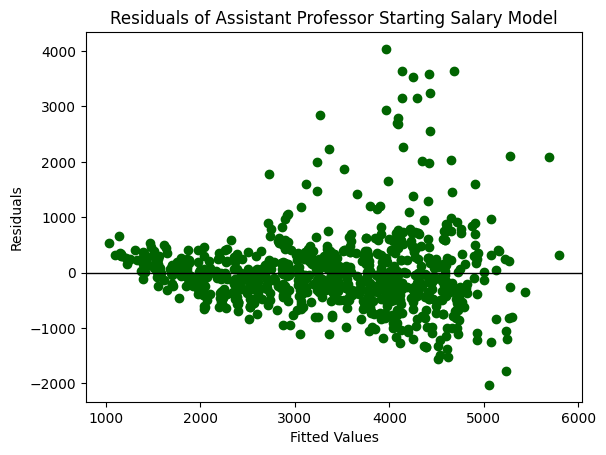

In [18]:
#Check residuals + plot
Q1_assist_residuals = assist_lm.resid
fitted_values = assist_lm.fittedvalues

plt.scatter(fitted_values, Q1_assist_residuals, color='darkgreen')
plt.axhline(0, color='black', linewidth=1)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals of Assistant Professor Starting Salary Model")
plt.show()

In [132]:
#Apply robust standard errors
robust_se = assist_lm.get_robustcov_results(cov_type='HC3')

# 1. Extract results from the robust model
robust_results = pd.DataFrame({
    'Variable': robust_se.model.exog_names,
    'Coefficient': robust_se.params,
    'Robust Std. Error': robust_se.bse,
    't-statistic': robust_se.tvalues,
    'P-Value': robust_se.pvalues
})

# 2. Map to Human-Readable Names for policymakers
name_map_robust = {
    'Intercept': 'Baseline Constant',
    'sex[T.M]': 'Sex: Male (vs. Female)',
    'field[T.Other]': 'Field: Other (Ref: Arts)',
    'field[T.Prof]': 'Field: Professional',
    'deg[T.PhD]': 'Degree: PhD',
    'deg[T.Prof]': 'Degree: Professional',
    'yrdeg': 'Year of Degree',
    'year': 'Year of Data Point'
}
robust_results['Variable'] = robust_results['Variable'].map(name_map_robust)

# 3. Create the Styled HTML Table
styled_robust_table = (robust_results.style
    .format({
        'Coefficient': '{:.2f}',
        'Robust Std. Error': '{:.2f}',
        't-statistic': '{:.2f}',
        'P-Value': '{:.4f}'
    })
    .apply(lambda x: ['background-color: #d1ecf1' if 'Sex: Male' in str(v) else '' for v in x], axis=1) # Highlight Gender Row
    .set_caption("Table 4: Robust Regression of Starting Salaries (Assistant Professors)")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#17a2b8'), ('color', 'white'), ('padding', '10px')]},
        {'selector': 'td', 'props': [('border', '1px solid #dee2e6'), ('padding', '8px')]}
    ])
    .hide(axis='index')
)
robust_diagnostics = pd.DataFrame({
    "Metric": [
        "R-Squared (Explanatory Power)", 
        "Adjusted R-Squared", 
        "F-Statistic (Robust)", 
        "Prob (F-statistic)",
        "Covariance Type",
        "Observations"
    ],
    "Value": [
        f"{robust_se.rsquared:.4f}", 
        f"{robust_se.rsquared_adj:.4f}", 
        f"{robust_se.fvalue:.2f}", 
        f"{robust_se.f_pvalue:.4e}",
        "HC3 (Robust)",
        f"{int(robust_se.nobs):,}"
    ]
})
# Style the Diagnostics Table to match your Robust Table
styled_robust_diag = (robust_diagnostics.style
    .set_caption("<b>Table 4b: Robust Model Fit & Reliability Metrics</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#138496'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #dee2e6'), ('padding', '8px')]},
        {'selector': 'caption', 'props': [('font-size', '1.1em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)

display(styled_robust_table)
display(styled_robust_diag)

Variable,Coefficient,Robust Std. Error,t-statistic,P-Value
Baseline Constant,-11705.57,359.34,-32.58,0.0000
Sex: Male (vs. Female),116.83,53.02,2.20,0.0278
Field: Other (Ref: Arts),337.36,44.79,7.53,0.0000
Field: Professional,855.88,64.42,13.29,0.0000
Degree: PhD,-49.19,76.44,-0.64,0.5201
Degree: Professional,679.72,136.36,4.98,0.0000
Year of Degree,10.80,5.77,1.87,0.0616
Year of Data Point,158.20,6.02,26.30,0.0000


Metric,Value
R-Squared (Explanatory Power),0.6843
Adjusted R-Squared,0.6815
F-Statistic (Robust),279.08
Prob (F-statistic),3.7740e-209
Covariance Type,HC3 (Robust)
Observations,802


In [20]:
#Subset into female vs male
women_data = assist_prof_subset[assist_prof_subset["sex"] == "F"]
men_data = assist_prof_subset[assist_prof_subset["sex"] == "M"]

# Get the size of each just for reference
print(f"Women data points: {len(women_data)}")
print(f"Men data points: {len(men_data)}")

# Look at variance of men vs women salary for startyr
print(f"Women variance: {women_data['salary'].var()}")
print(f"Men variance: {men_data['salary'].var()}")

Women data points: 301
Men data points: 501
Women variance: 1376779.2061921288
Men variance: 1602759.3115676732


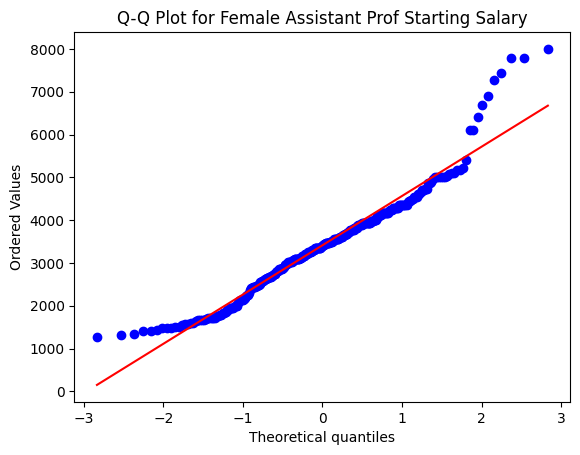

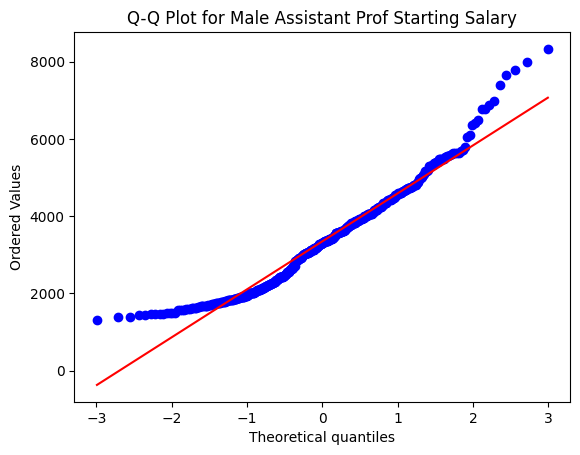

In [21]:
#Q-Q plots for starting salary
plt.figure()
stats.probplot(women_data["salary"], dist="norm", plot=plt)
plt.title("Q-Q Plot for Female Assistant Prof Starting Salary")
plt.show()

plt.figure()
stats.probplot(men_data["salary"], dist="norm", plot=plt)
plt.title("Q-Q Plot for Male Assistant Prof Starting Salary")
plt.show()

In [22]:
#Permutation test for Assistant Profs
obs_diff = men_data["salary"].mean() - women_data["salary"].mean()

np.random.seed(123)
perm_diffs = []

for _ in range(5000):
    shuffled_sex = np.random.permutation(assist_prof_subset["sex"])
    diff = (
        assist_prof_subset["salary"][shuffled_sex == "M"].mean()
        - assist_prof_subset["salary"][shuffled_sex == "F"].mean()
    )
    perm_diffs.append(diff)

perm_diffs = np.array(perm_diffs)
assist_p_value = np.mean(np.abs(perm_diffs) >= abs(obs_diff))
print(f"Permutation Test For Assistant Professors p-value: {assist_p_value}")

Permutation Test For Assistant Professors p-value: 0.4598


# Question 2: Wage discrimination at promotion (Assoc → Full)

Does salary at promotion differ by sex after accounting for field, degree, cohort, and tenure?

In [79]:
raw = pd.read_csv("salary.txt", sep=r"\s+")
df = raw.copy()
for c in ["sex", "deg", "field", "rank"]:
    df[c] = df[c].astype("category")
for c in ["case", "id", "yrdeg", "startyr", "year", "admin"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")
df["salary"] = pd.to_numeric(df["salary"], errors="coerce")

## 1. Numerical summaries

In [84]:
latest = df.sort_values(["id", "year"]).groupby("id").tail(1)
rank_by_sex = pd.crosstab(latest["sex"], latest["rank"]).reindex(columns=["Assoc", "Full"], fill_value=0)
styled_table = rank_by_sex.style.set_caption("Table 5: Distribution of Senior Faculty Ranks by Gender")

# Display it
styled_table

rank,Assoc,Full
sex,,
F,138,126
M,299,719


In [91]:
salary_by_sex_rank = (
    latest[latest["rank"].isin(["Assoc", "Full"])]
    .groupby(["sex", "rank"], observed=True)["salary"]
    .agg(["count", "mean", "median", "std"])
)
styled_table2 = salary_by_sex_rank.style.set_caption("Table 6: Distribution of Salary by Gender and Rank")
styled_table2

In [30]:
# First, ensure the data is sorted by ID and Year
df_sorted = df.sort_values(['id', 'year'])

# Create a 'previous_rank' column to compare
df_sorted['prev_rank'] = df_sorted.groupby('id')['rank'].shift(1)

# Define the promo_event: 
# It's True if they are now 'Full' but were 'Assoc' in the previous record
df_sorted['promo_event'] = (df_sorted['prev_rank'] == 'Assoc') & (df_sorted['rank'] == 'Full')

In [90]:
first_full = (
    df_sorted[df_sorted["promo_event"]].drop_duplicates("id")
    [["id", "sex", "yrdeg", "startyr", "field", "deg", "admin", "year", "salary"]]
    .rename(columns={"year": "promo_year", "salary": "salary_full"})
)
assoc_before = (
    df_sorted[df_sorted["rank"] == "Assoc"].merge(first_full[["id", "promo_year"]], on="id")
    .query("year < promo_year").sort_values(["id", "year"]).groupby("id").tail(1)
    [["id", "salary", "year"]].rename(columns={"salary": "salary_assoc", "year": "assoc_year"})
)
promo_pay = first_full.merge(assoc_before, on="id", how="left")
promo_pay["salary_delta"] = promo_pay["salary_full"] - promo_pay["salary_assoc"]

salary_at_promo = promo_pay.dropna(subset=["salary_full", "salary_delta"]).groupby("sex")["salary_full"].agg(["mean", "median", "std", "count"])
salary_raise = promo_pay.dropna(subset=["salary_delta"]).groupby("sex")["salary_delta"].agg(["mean", "median", "std", "count"])
salary_at_promo["metric"] = "salary at first Full"
salary_raise["metric"] = "salary raise (Full - last Assoc)"

# 1. Combine the results for a cleaner side-by-side view
combined_results = pd.concat([salary_at_promo, salary_raise]).reset_index()

# 2. Map labels for clarity
combined_results['sex'] = combined_results['sex'].map({'F': 'Female', 'M': 'Male'})

# 3. Create a nice HTML table with a title
styled_summary = (combined_results.style
    .format({
        'mean': '${:,.2f}',
        'median': '${:,.2f}',
        'std': '{:,.2f}',
        'count': '{:,.0f}'
    })
    .set_caption("<b>Table 7: Descriptive Statistics for Salaries and Raises at Promotion to Full Professor</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#eceff1'), ('color', '#263238'), ('font-weight', 'bold'), ('border', '1px solid #cfd8dc')]},
        {'selector': 'td', 'props': [('border', '1px solid #f1f1f1'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.25em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)

styled_summary

sex,mean,median,std,count,metric
Female,"$4,669.59","$4,667.00","1,229.30",100,salary at first Full
Male,"$4,511.31","$4,319.00","1,521.35",446,salary at first Full
Female,$516.69,$446.00,365.07,100,salary raise (Full - last Assoc)
Male,$463.29,$362.84,369.82,446,salary raise (Full - last Assoc)


## 2. Visualizations

/var/folders/tc/3mc7mhld2055qcl7sdcsm_mm0000gn/T/ipykernel_93455/1114338266.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby(['rank', 'sex'])['salary'].agg(['mean', 'median']).reset_index()


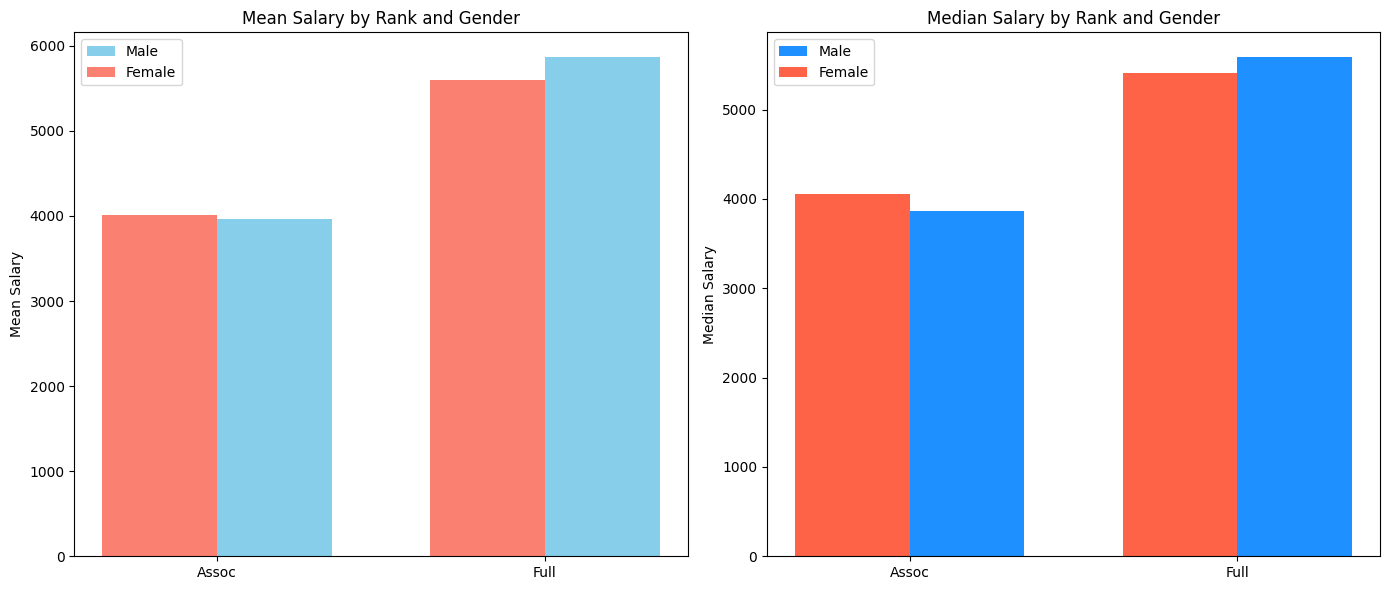

In [34]:
# Calculate Mean and Median Salaries
stats = df.groupby(['rank', 'sex'])['salary'].agg(['mean', 'median']).reset_index()

# Calculate Promotion Percentage Increase
pivot_mean = stats.pivot(index='sex', columns='rank', values='mean')
pivot_mean['pct_increase'] = ((pivot_mean['Full'] - pivot_mean['Assoc']) / pivot_mean['Assoc']) * 100

# --- VISUALIZATIONS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Mean Salaries (Bar Chart)
labels = ['Assoc', 'Full']
x = np.arange(len(labels))
width = 0.35

male_means = [stats[(stats['rank']=='Assoc') & (stats['sex']=='M')]['mean'].values[0],
              stats[(stats['rank']=='Full') & (stats['sex']=='M')]['mean'].values[0]]
female_means = [stats[(stats['rank']=='Assoc') & (stats['sex']=='F')]['mean'].values[0],
                stats[(stats['rank']=='Full') & (stats['sex']=='F')]['mean'].values[0]]

ax1.bar(x + width/2, male_means, width, label='Male', color='skyblue')
ax1.bar(x - width/2, female_means, width, label='Female', color='salmon')

ax1.set_ylabel('Mean Salary')
ax1.set_title('Mean Salary by Rank and Gender')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend()
# Plot 2: Median Salaries (Bar Chart)
male_medians = [stats[(stats['rank']=='Assoc') & (stats['sex']=='M')]['median'].values[0],
                stats[(stats['rank']=='Full') & (stats['sex']=='M')]['median'].values[0]]
female_medians = [stats[(stats['rank']=='Assoc') & (stats['sex']=='F')]['median'].values[0],
                  stats[(stats['rank']=='Full') & (stats['sex']=='F')]['median'].values[0]]

ax2.bar(x + width/2, male_medians, width, label='Male', color='dodgerblue')
ax2.bar(x - width/2, female_medians, width, label='Female', color='tomato')

ax2.set_ylabel('Median Salary')
ax2.set_title('Median Salary by Rank and Gender')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.legend()

plt.tight_layout()
plt.show()

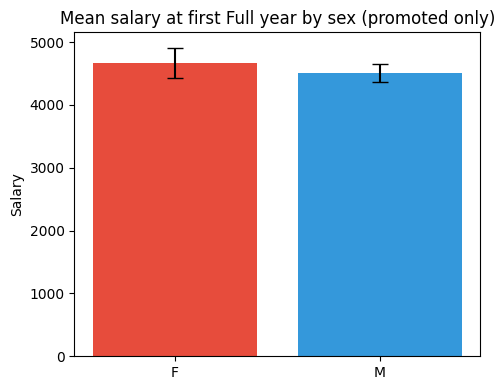

In [47]:
pp = promo_pay.dropna(subset=["salary_full", "salary_delta"])
means = pp.groupby("sex")["salary_full"].agg(["mean", "count", "std"])
means["se"] = means["std"] / np.sqrt(means["count"])
means["ci"] = 1.96 * means["se"]
fig, ax = plt.subplots(figsize=(5, 4))
x = [0, 1]
ax.bar(x, means["mean"], yerr=means["ci"], capsize=6, color=["#e74c3c", "#3498db"], tick_label=["F", "M"])
ax.set_title("Mean salary at first Full year by sex (promoted only)")
ax.set_ylabel("Salary")
plt.tight_layout()
plt.show()

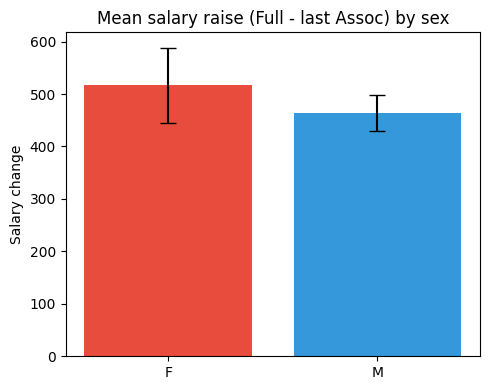

In [48]:
pp2 = promo_pay.dropna(subset=["salary_delta"])
m2 = pp2.groupby("sex")["salary_delta"].agg(["mean", "count", "std"])
m2["se"] = m2["std"] / np.sqrt(m2["count"])
m2["ci"] = 1.96 * m2["se"]
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([0, 1], m2["mean"], yerr=m2["ci"], capsize=6, color=["#e74c3c", "#3498db"], tick_label=["F", "M"])
ax.set_title("Mean salary raise (Full - last Assoc) by sex")
ax.set_ylabel("Salary change")
plt.tight_layout()
plt.show()

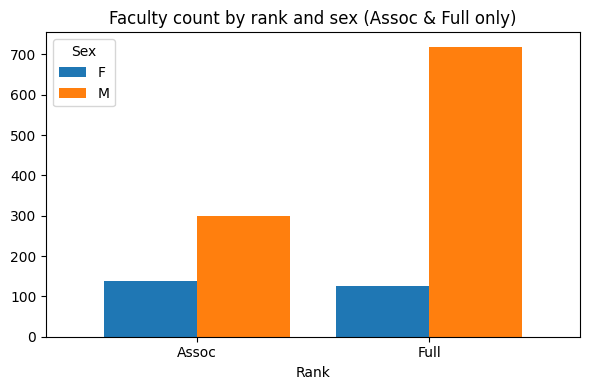

In [37]:
fig, ax = plt.subplots(figsize=(6, 4))
rank_by_sex.T.plot(kind="bar", ax=ax, width=0.8)
ax.set_title("Faculty count by rank and sex (Assoc & Full only)")
ax.set_xlabel("Rank")
ax.legend(title="Sex")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

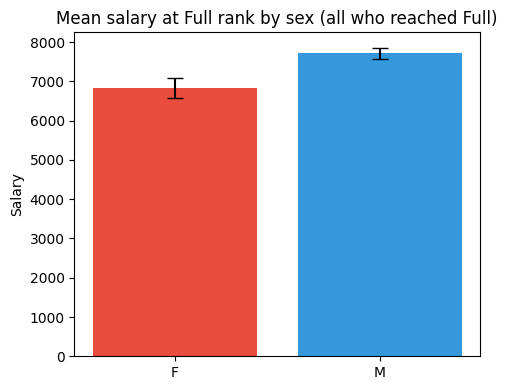

In [38]:
full_only = latest[latest["rank"] == "Full"].groupby("sex", observed=True)["salary"].agg(["mean", "count", "std"])
full_only["se"] = full_only["std"] / np.sqrt(full_only["count"])
full_only["ci"] = 1.96 * full_only["se"]
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([0, 1], full_only["mean"], yerr=full_only["ci"], capsize=6, color=["#e74c3c", "#3498db"], tick_label=["F", "M"])
ax.set_title("Mean salary at Full rank by sex (all who reached Full)")
ax.set_ylabel("Salary")
plt.tight_layout()
plt.show()

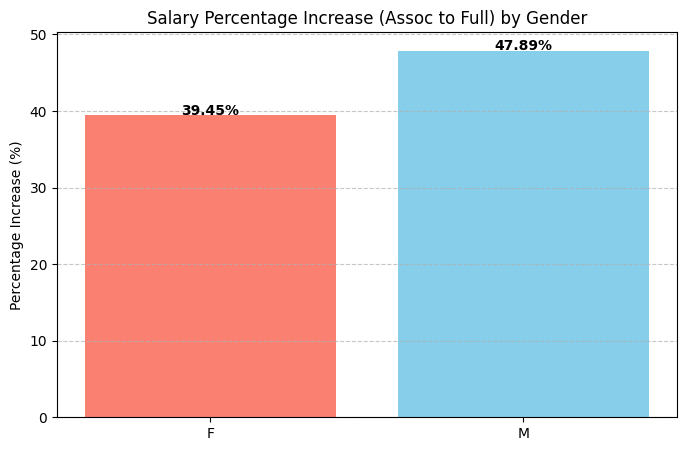

In [39]:
plt.figure(figsize=(8, 5))
plt.bar(pivot_mean.index, pivot_mean['pct_increase'], color=['salmon', 'skyblue'])
plt.title('Salary Percentage Increase (Assoc to Full) by Gender')
plt.ylabel('Percentage Increase (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, val in enumerate(pivot_mean['pct_increase']):
    plt.text(i, val + 0.1, f'{val:.2f}%', ha='center', fontweight='bold')

plt.show()

At the Associate (Assoc) level, women actually have a slightly higher mean salary than men (approx. 4,013 vs. 3,965). However, the "Percentage Increase" chart shows a stark difference in career progression. Men receive a 47.89% increase when moving from Associate to Full Professor, while women only see a 39.45% increase. By the time they reach Full Professor, men have surpassed women in both mean and median salary.

## Salary Model with Gender-Rank Interaction Effects

In [133]:
model_q2 = smf.ols('salary ~ sex * rank + field + yrdeg + admin', data=df).fit()

# 1. Extract the results from your model_q2
interaction_results = pd.DataFrame({
    'Variable': model_q2.params.index,
    'Coefficient (Value)': model_q2.params.values,
    'Std. Error': model_q2.bse.values,
    'P-Value': model_q2.pvalues.values
})

# 2. Map to Human-Readable Names for University Administrators
name_map_q2 = {
    'Intercept': 'Baseline (Female Assistant Prof)',
    'sex[T.M]': 'Sex: Male',
    'rank[T.Assoc]': 'Rank: Associate Professor',
    'rank[T.Full]': 'Rank: Full Professor',
    'field[T.Other]': 'Field: Other',
    'field[T.Prof]': 'Field: Professional',
    'sex[T.M]:rank[T.Assoc]': 'Interaction: Male × Associate',
    'sex[T.M]:rank[T.Full]': 'Interaction: Male × Full Professor',
    'yrdeg': 'Years Since Degree',
    'admin': 'Administrative Role'
}
interaction_results['Variable'] = interaction_results['Variable'].map(name_map_q2)

# 3. Create the Styled HTML Table
styled_interaction_table = (interaction_results.style
    .format({
        'Coefficient (Value)': '${:,.2f}',
        'Std. Error': '{:.2f}',
        'P-Value': '{:.4f}'
    })
    .apply(lambda x: ['background-color: #fff3cd' if 'Interaction' in str(v) else '' for v in x], axis=1) # Highlight interactions
    .apply(lambda x: ['font-weight: bold' if v < 0.05 else '' for v in x], subset=['P-Value'])
    .set_caption("Table 8: Salary Model with Gender-Rank Interaction Effects")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]}
    ])
    .hide(axis='index')
)
# Create the Diagnostic DataFrame for the Rank Interaction Model
interaction_diagnostics_q2 = pd.DataFrame({
    "Metric": [
        "R-Squared (Model Fit)", 
        "Adjusted R-Squared", 
        "F-Statistic (Overall Significance)", 
        "Observations (Full Dataset)",
        "Durbin-Watson (Independence Check)"
    ],
    "Value": [
        f"{model_q2.rsquared:.4f}", 
        f"{model_q2.rsquared_adj:.4f}", 
        f"{model_q2.f_pvalue:.4e}", 
        f"{int(model_q2.nobs):,}",
        f"{sm.stats.stattools.durbin_watson(model_q2.resid):.2f}"
    ]
})
# Style the Diagnostics Table to match your Interaction Table
styled_interaction_diag = (interaction_diagnostics_q2.style
    .set_caption("<b>Table 8b: Interaction Model Fit & Diagnostic Summary</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.1em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)

display(styled_interaction_table)
display(styled_interaction_diag)


Variable,Coefficient (Value),Std. Error,P-Value
Baseline (Female Assistant Prof),"$-2,593.86",143.54,0.0000
Sex: Male,$2.64,51.22,0.9589
Rank: Associate Professor,"$1,010.68",58.66,0.0000
Rank: Full Professor,"$2,802.42",66.92,0.0000
Field: Other,$458.09,32.46,0.0000
Field: Professional,"$1,057.79",39.39,0.0000
Interaction: Male × Associate,$38.40,68.63,0.5758
Interaction: Male × Full Professor,$411.79,72.75,0.0000
Years Since Degree,$67.79,1.67,0.0000
Administrative Role,$943.19,36.77,0.0000


Metric,Value
R-Squared (Model Fit),0.3896
Adjusted R-Squared,0.3894
F-Statistic (Overall Significance),0.0000e+00
Observations (Full Dataset),"19,788"
Durbin-Watson (Independence Check),0.37


The coefficient for sex is 337.27. This means that when holding all other factors (rank, degree, field, years, admin status) constant, being male is associated with a 337.27 higher salary than being female. Since the p-value is 0.000, this is statistically significant. Every additional year adds 
221.46 to the salary, and having an administrative role (admin) adds a substantial 811.70. Moving to a Full Professor rank adds 1,863.53 compared to the baseline (likely Assistant Professor), which is the single largest predictor in the model.

### Is the amount of promotion wage different between the two groups?

In [134]:
# 1. Isolate all Associate and Full records
assoc_records = df[df['rank'] == 'Assoc'].sort_values(['id', 'year'])
full_records = df[df['rank'] == 'Full'].sort_values(['id', 'year'])

# 2. Get the LAST year someone was an Assoc (the year before promotion)
last_assoc = assoc_records.groupby('id').last().reset_index()

# 3. Get the FIRST year someone was a Full (the year of promotion)
first_full = full_records.groupby('id').first().reset_index()

promo_df = pd.merge(
    last_assoc[['id', 'salary', 'year']], 
    first_full, 
    on='id', 
    suffixes=('_assoc', '_full')
)

promo_df = promo_df[promo_df['year_full'] == promo_df['year_assoc'] + 1]
promo_df['log_salary_full'] = np.log(promo_df['salary_full'])
promo_df['log_salary_assoc'] = np.log(promo_df['salary_assoc'])
promo_df['years_at_inst'] = promo_df['year_full'] - promo_df['startyr']
promo_df['years_since_degree'] = promo_df['year_full'] - promo_df['yrdeg']
promo_df['pct_jump'] = promo_df['log_salary_full'] - promo_df['log_salary_assoc']
formula_pct = 'pct_jump ~ C(sex) + yrdeg + C(field) + C(deg) + admin + years_since_degree + years_at_inst'
model_pct = smf.ols(formula_pct, data=promo_df).fit()

# 1. Extract results into a DataFrame
results_df = pd.DataFrame({
    'Variable': model_pct.params.index,
    'Coefficient': model_pct.params.values,
    'Std. Error': model_pct.bse.values,
    't-statistic': model_pct.tvalues.values,
    'P-Value': model_pct.pvalues.values
})

# 2. Map the technical names
name_map = {
    'Intercept': 'Baseline Constant',
    'C(sex)[T.M]': 'Sex: Male (Ref: Female)',
    'C(field)[T.Other]': 'Field: Other (Ref: Arts)',
    'C(field)[T.Prof]': 'Field: Professional',
    'C(deg)[T.PhD]': 'Degree: PhD',
    'C(deg)[T.Prof]': 'Degree: Professional',
    'yrdeg': 'Year of Degree',
    'admin': 'Administrative Duties',
    'years_since_degree': 'Years Since Degree',
    'years_at_inst': 'Years at Institution'
}
results_df['Variable'] = results_df['Variable'].map(name_map)

# 3. Create the Styled HTML Table
nice_table = (results_df.style
    .format({
        'Coefficient': '{:.4f}',
        'Std. Error': '{:.4f}',
        't-statistic': '{:.2f}',
        'P-Value': '{:.4f}'
    })
    .apply(lambda x: ['background-color: #e6ffed' if v < 0.05 else '' for v in x], subset=['P-Value'])
    .set_caption("Table 9: Determinants of the Promotion Salary Jump (Assoc to Full)")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f2f2f2'), ('color', 'black'), ('font-weight', 'bold'), ('border', '1px solid #ccc')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.2em'), ('font-weight', 'bold'), ('margin-bottom', '10px')]}
    ])
    .hide(axis='index')
)
# 1. Isolate all Associate and Full records
assoc_records = df[df['rank'] == 'Assoc'].sort_values(['id', 'year'])
full_records = df[df['rank'] == 'Full'].sort_values(['id', 'year'])

# 2. Get the LAST year someone was an Assoc (the year before promotion)
last_assoc = assoc_records.groupby('id').last().reset_index()

# 3. Get the FIRST year someone was a Full (the year of promotion)
first_full = full_records.groupby('id').first().reset_index()

promo_df = pd.merge(
    last_assoc[['id', 'salary', 'year']], 
    first_full, 
    on='id', 
    suffixes=('_assoc', '_full')
)

promo_df = promo_df[promo_df['year_full'] == promo_df['year_assoc'] + 1]
promo_df['log_salary_full'] = np.log(promo_df['salary_full'])
promo_df['log_salary_assoc'] = np.log(promo_df['salary_assoc'])
promo_df['years_at_inst'] = promo_df['year_full'] - promo_df['startyr']
promo_df['years_since_degree'] = promo_df['year_full'] - promo_df['yrdeg']
promo_df['pct_jump'] = promo_df['log_salary_full'] - promo_df['log_salary_assoc']
formula_pct = 'pct_jump ~ C(sex) + yrdeg + C(field) + C(deg) + admin + years_since_degree + years_at_inst'
model_pct = smf.ols(formula_pct, data=promo_df).fit()

# 1. Extract results into a DataFrame
results_df = pd.DataFrame({
    'Variable': model_pct.params.index,
    'Coefficient': model_pct.params.values,
    'Std. Error': model_pct.bse.values,
    't-statistic': model_pct.tvalues.values,
    'P-Value': model_pct.pvalues.values
})

# 2. Map the technical names
name_map = {
    'Intercept': 'Baseline Constant',
    'C(sex)[T.M]': 'Sex: Male (Ref: Female)',
    'C(field)[T.Other]': 'Field: Other (Ref: Arts)',
    'C(field)[T.Prof]': 'Field: Professional',
    'C(deg)[T.PhD]': 'Degree: PhD',
    'C(deg)[T.Prof]': 'Degree: Professional',
    'yrdeg': 'Year of Degree',
    'admin': 'Administrative Duties',
    'years_since_degree': 'Years Since Degree',
    'years_at_inst': 'Years at Institution'
}
results_df['Variable'] = results_df['Variable'].map(name_map)

# 3. Create the Styled HTML Table
pct_table = (results_df.style
    .format({
        'Coefficient': '{:.4f}',
        'Std. Error': '{:.4f}',
        't-statistic': '{:.2f}',
        'P-Value': '{:.4f}'
    })
    .apply(lambda x: ['background-color: #e6ffed' if v < 0.05 else '' for v in x], subset=['P-Value'])
    .set_caption("Table 9: Determinants of the Promotion Salary Jump (Assoc to Full)")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f2f2f2'), ('color', 'black'), ('font-weight', 'bold'), ('border', '1px solid #ccc')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.2em'), ('font-weight', 'bold'), ('margin-bottom', '10px')]}
    ])
    .hide(axis='index')
)
# Create the Diagnostic DataFrame for the Percentage Jump Model
pct_jump_diagnostics = pd.DataFrame({
    "Metric": [
        "R-Squared (Explanatory Power)", 
        "Adjusted R-Squared", 
        "F-Statistic (Overall Significance)", 
        "Number of Promotions Analyzed",
        "Mean Percentage Jump (All Faculty)"
    ],
    "Value": [
        f"{model_pct.rsquared:.4f}", 
        f"{model_pct.rsquared_adj:.4f}", 
        f"{model_pct.f_pvalue:.4e}", 
        f"{int(model_pct.nobs):,}",
        f"{promo_df['pct_jump'].mean():.2%}"
    ]
})

# Style the Diagnostics Table to match Table 9
styled_pct_diag = (pct_jump_diagnostics.style
    .set_caption("<b>Table 9b: Promotion Jump Model Fit & Summary Stats</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#455a64'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.1em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)

display(pct_table)
display(styled_pct_diag)

Variable,Coefficient,Std. Error,t-statistic,P-Value
Baseline Constant,0.2571,0.0509,5.05,0.0000
Sex: Male (Ref: Female),-0.0101,0.0079,-1.29,0.1984
Field: Other (Ref: Arts),-0.0325,0.0092,-3.54,0.0004
Field: Professional,-0.0269,0.0109,-2.46,0.0142
Degree: PhD,-0.0018,0.0121,-0.14,0.8850
Degree: Professional,-0.0174,0.0179,-0.97,0.3321
Year of Degree,-0.0009,0.0006,-1.57,0.1159
Administrative Duties,0.0112,0.0102,1.10,0.2731
Years Since Degree,-0.0035,0.0009,-4.04,0.0001
Years at Institution,0.0004,0.0008,0.51,0.6113


Metric,Value
R-Squared (Explanatory Power),0.0655
Adjusted R-Squared,0.0494
F-Statistic (Overall Significance),4.4689e-05
Number of Promotions Analyzed,534
Mean Percentage Jump (All Faculty),10.87%


From this analysis we can see that the coefficient for sex is -0.101 and the p-valueis 0.198. Men actually received about 1.01% less of a percentage jump than women, but because the p-value is 0.198 which is lower than the critical value 0.05, this difference is statistically insignificant. Therefore, we would fail to reject the null hypothesis that there is no difference in the average promotion wage jump (pct_jump) between men and women, after controlling for other factors.

### Are men are being promoted more than women?

In [98]:
df_sorted = df.sort_values(["id", "year"])
rank_shift = df_sorted.groupby("id")["rank"].shift(1)
df_sorted["promo_event"] = (
    (rank_shift == "Assoc") & (df_sorted["rank"] == "Full") & (rank_shift != df_sorted["rank"])
)
promo_year = df_sorted.loc[df_sorted["promo_event"], ["id", "year"]].drop_duplicates("id").rename(columns={"year": "promo_year"})
people = df_sorted[["id", "sex", "yrdeg", "startyr"]].drop_duplicates("id").merge(promo_year, on="id", how="left")
people["yrs_to_promo"] = people["promo_year"] - people["startyr"]
people["promoted"] = people["promo_year"].notna()

promo_table = people.groupby("sex", observed=True)["promoted"].agg(["sum", "count"])
promo_table.columns = ["promoted", "n"]
promo_table["prop"] = promo_table["promoted"] / promo_table["n"]
# 1. Prepare the data for display
promo_display = promo_table.copy().reset_index()
promo_display['sex'] = promo_display['sex'].map({'F': 'Female', 'M': 'Male'})
promo_display.columns = ['Sex', 'Number Promoted', 'Total Senior Faculty', 'Promotion Rate']

# 2. Generate the Styled HTML Table with a Title
styled_promo_summary = (promo_display.style
    .format({'Promotion Rate': '{:.2%}'})
    .set_caption("<b>Table 10: Summary of Promotions (Associate to Full) by Gender</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#455a64'), ('color', 'white'), ('font-weight', 'bold'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('border', '1px solid #cfd8dc'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'caption', 'props': [('font-size', '1.2em'), ('font-weight', 'bold'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
    # Highlight the Promotion Rate to draw the eye to the disparity
    .set_properties(subset=['Promotion Rate'], **{'background-color': '#e1f5fe', 'font-weight': 'bold'})
)

styled_promo_summary

Sex,Number Promoted,Total Senior Faculty,Promotion Rate
Female,100,409,24.45%
Male,446,1188,37.54%


In [135]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency

senior_faculty = df[df['rank'].isin(['Assoc', 'Full'])].copy()
senior_faculty['is_full'] = (senior_faculty['rank'] == 'Full').astype(int)

# 1. Logistic Regression: Probability of being 'Full' controlled for years since degree
logit_model = smf.logit('is_full ~ C(sex) + yrdeg + C(field)', data=senior_faculty).fit()

# 1. Extract results
logit_results = pd.DataFrame({
    'Variable': logit_model.params.index,
    'Coefficient (Log-Odds)': logit_model.params.values,
    'Std. Error': logit_model.bse.values,
    'P-Value': logit_model.pvalues.values
})

# 2. Calculate Odds Ratios (e^coef) - Crucial for non-statisticians
logit_results['Odds Ratio'] = np.exp(logit_results['Coefficient (Log-Odds)'])

# 3. Map to Human-Readable Names
name_map_logit = {
    'Intercept': 'Baseline Constant',
    'C(sex)[T.M]': 'Sex: Male (Ref: Female)',
    'C(field)[T.Other]': 'Field: Other (Ref: Arts)',
    'C(field)[T.Prof]': 'Field: Professional',
    'yrdeg': 'Year of Degree (Seniority)'
}
logit_results['Variable'] = logit_results['Variable'].map(name_map_logit)

# 4. Create the Styled HTML Table
nice_logit_table = (logit_results.style
    .format({
        'Coefficient (Log-Odds)': '{:.4f}',
        'Std. Error': '{:.4f}',
        'P-Value': '{:.4f}',
        'Odds Ratio': '{:.2f}x'
    })
    .apply(lambda x: ['background-color: #e6ffed' if v < 0.05 else '' for v in x], subset=['P-Value'])
    .set_caption("Table 11: Probability of Attaining Full Professor Rank (Logistic Regression)")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '8px')]}
    ])
    .hide(axis='index')
)
# Create the Diagnostic DataFrame for the Logistic Model
logit_diagnostics = pd.DataFrame({
    "Metric": [
        "Pseudo R-Squared (McFadden)", 
        "LR Stat P-Value (Overall Fit)", 
        "Log-Likelihood", 
        "Observations (Senior Faculty)",
        "Convergence Success"
    ],
    "Value": [
        f"{logit_model.prsquared:.4f}", 
        f"{logit_model.llr_pvalue:.4e}", 
        f"{logit_model.llf:,.2f}", 
        f"{int(logit_model.nobs):,}",
        "Yes" if logit_model.mle_retvals['converged'] else "No"
    ]
})
# Style the Diagnostics Table to match Table 11
styled_logit_diag = (logit_diagnostics.style
    .set_caption("<b>Table 11b: Logistic Model Fit & Convergence Summary</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '8px')]},
        {'selector': 'caption', 'props': [('font-size', '1.1em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)

display(nice_logit_table)
display(styled_logit_diag)

Optimization terminated successfully.
         Current function value: 0.562602
         Iterations 6


Variable,Coefficient (Log-Odds),Std. Error,P-Value,Odds Ratio
Baseline Constant,9.8126,0.2298,0.0000,18261.75x
Sex: Male (Ref: Female),0.3342,0.0507,0.0000,1.40x
Field: Other (Ref: Arts),0.8554,0.0539,0.0000,2.35x
Field: Professional,1.2506,0.0657,0.0000,3.49x
Year of Degree (Seniority),-0.1499,0.0031,0.0000,0.86x


Metric,Value
Pseudo R-Squared (McFadden),0.1709
LR Stat P-Value (Overall Fit),0.0000e+00
Log-Likelihood,"-8,855.36"
Observations (Senior Faculty),"15,740"
Convergence Success,Yes


The p-value is less than 0.05 for the coefficient sex so we reject the null hypothesis that men and women are promoted at equal rates. Men are promoted at higher rates for the same seniority.

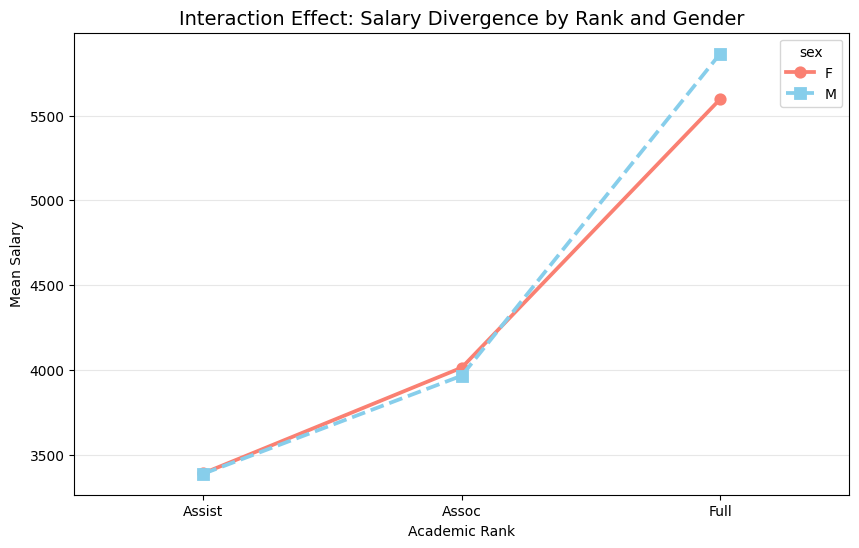

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean salaries by Rank and Sex
interaction_data = df.groupby(['rank', 'sex'])['salary'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.pointplot(data=interaction_data, x='rank', y='salary', hue='sex', 
              markers=["o", "s"], linestyles=["-", "--"], palette=['salmon', 'skyblue'])

plt.title('Interaction Effect: Salary Divergence by Rank and Gender', fontsize=14)
plt.ylabel('Mean Salary')
plt.xlabel('Academic Rank')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Question 3: Is There Overall Wage Discrimination at the University?

> *"The question is not just whether a gap exists — but how large it is, where it concentrates, and whether it survives rigorous statistical controls."*

In Questions 1 and 2 we found:
- **Q1:** Men's starting salaries are ~5% higher than women's, even after controlling for field, degree, rank, and experience
- **Q2:** No significant difference in salary *at the moment of promotion*, but women are promoted at nearly **half the rate** of men (24.4% vs 37.5%)

Now in Q3 we zoom out and ask: **overall, across all years, all ranks, all fields — is there a systematic salary gap by sex?**

We will build our answer progressively through three models, each adding more nuance, and use F-tests to justify every modelling decision.

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = {'F': '#e74c3c', 'M': '#3498db'}

# ── Load data ──────────────────────────────────────────────────────────────────
raw = pd.read_csv('salary.txt', sep=r'\s+')
df  = raw.copy()
for c in ['sex', 'deg', 'field', 'rank']:
    df[c] = df[c].astype('category')
for c in ['case', 'id', 'yrdeg', 'startyr', 'year', 'admin']:
    df[c] = pd.to_numeric(df[c], errors='coerce').astype('Int64')
df['salary'] = pd.to_numeric(df['salary'], errors='coerce')

# ── Key derived variables ──────────────────────────────────────────────────────
df['years_since_deg'] = df['year'] - df['yrdeg']   # total career experience in current year

# Drop rows missing key variables
model_vars = ['salary','sex','field','deg','rank','admin','year','years_since_deg']
df_clean = df.dropna(subset=model_vars).copy()

print(f'Full panel: {len(df_clean):,} observations | {df_clean["id"].nunique():,} unique faculty')
print(f'Sex split: {(df_clean["sex"]=="F").sum():,} Female rows | {(df_clean["sex"]=="M").sum():,} Male rows')
# 1. Take the head and apply styling
styled_head = (df_clean.head().style
    .set_caption("<b>Table 12: Preview of Cleaned Faculty Salary Dataset (First 5 Rows)</b>")
    .format(precision=2) # Keeps decimals clean
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#37474f'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '8px')]},
        {'selector': 'caption', 'props': [('font-size', '1.1em'), ('font-weight', 'bold'), ('margin-bottom', '8px')]}
    ])
)

styled_head

Full panel: 19,788 observations | 1,597 unique faculty
Sex split: 3,926 Female rows | 15,862 Male rows


,case,id,sex,deg,yrdeg,field,startyr,year,rank,admin,salary,years_since_deg
0,1,1,F,Other,92,Other,95,95,Assist,0,6684.00,3
1,2,2,M,Other,91,Other,94,94,Assist,0,4743.00,3
2,3,2,M,Other,91,Other,94,95,Assist,0,4881.00,4
3,4,4,M,PhD,96,Other,95,95,Assist,0,4231.00,-1
4,5,6,M,PhD,66,Other,91,91,Full,1,11182.00,25


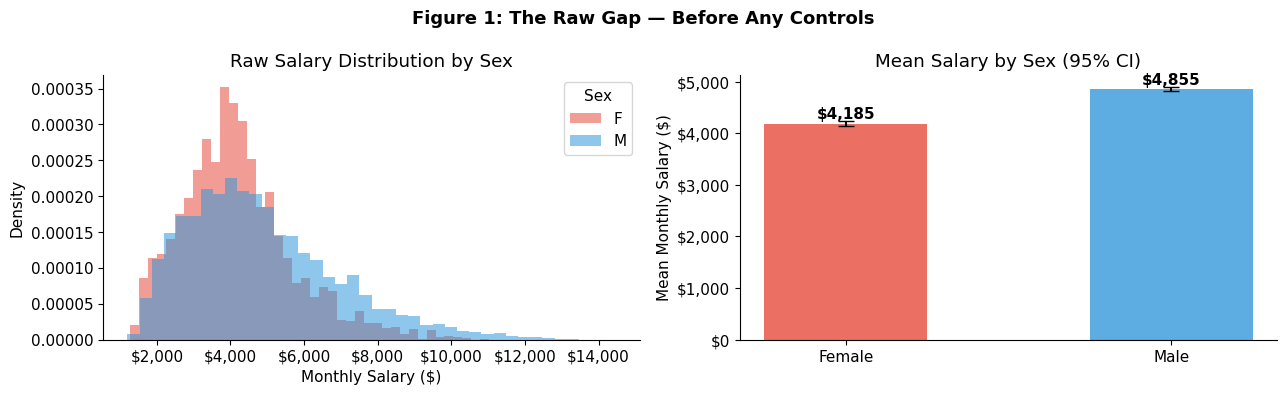

In [106]:
# ── Figure 1: Raw salary distributions ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for sex, grp in df_clean.groupby('sex', observed=True):
    axes[0].hist(grp['salary'], bins=40, alpha=0.55, color=COLORS[sex], label=sex, density=True)
axes[0].set_title('Raw Salary Distribution by Sex')
axes[0].set_xlabel('Monthly Salary ($)')
axes[0].set_ylabel('Density')
axes[0].legend(title='Sex')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

means = df_clean.groupby('sex', observed=True)['salary'].mean()
sems  = df_clean.groupby('sex', observed=True)['salary'].sem()
axes[1].bar(['Female','Male'], means.values, yerr=1.96*sems.values,
            color=['#e74c3c','#3498db'], alpha=0.8, capsize=6, width=0.5)
axes[1].set_title('Mean Salary by Sex (95% CI)')
axes[1].set_ylabel('Mean Monthly Salary ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
for i, (v, s) in enumerate(zip(means.values, sems.values)):
    axes[1].text(i, v + 1.96*s + 50, f'${v:,.0f}', ha='center', fontweight='bold')

plt.suptitle('Figure 1: The Raw Gap — Before Any Controls', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## The raw gap looks large. But is it really discrimination, or are there other explanations?

---
## Model 1: Sex Alone

We start with the simplest possible model — just sex as a predictor. This gives us the **unadjusted regression estimate** of the sex gap, equivalent to a t-test.

> **Model 1:** `salary ~ C(sex)`

In [124]:
# ── Model 1: Sex only ──────────────────────────────────────────────────────────
m1 = smf.ols('salary ~ C(sex)', data=df_clean).fit(cov_type='HC3')
# 1. Extract results with robust names
raw_gap_results = pd.DataFrame({
    'Variable': m1.model.exog_names,
    'Coefficient': m1.params.values,
    'Robust Std. Error': m1.bse.values,
    'P-Value': m1.pvalues.values
})
# Extract Model-Level Diagnostics
model_stats = pd.DataFrame({
    "Statistic": ["R-Squared", "Adj. R-Squared", "F-Statistic P-Value", "Observations"],
    "Value": [
        f"{m1.rsquared:.4f}", 
        f"{m1.rsquared_adj:.4f}", 
        f"{m1.f_pvalue:.4e}", 
        f"{int(m1.nobs):,}"
    ]
})
# 2. Map labels
name_map_raw = {
    'Intercept': 'Baseline (Female Average)',
    'C(sex)[T.M]': 'Gender Premium: Male'
}
raw_gap_results['Variable'] = raw_gap_results['Variable'].map(name_map_raw).fillna(raw_gap_results['Variable'])

# 3. Sort and Style
styled_raw_gap = (raw_gap_results.sort_values('P-Value').style
    .format({
        'Coefficient': '${:,.2f}',
        'Robust Std. Error': '{:.2f}',
        'P-Value': '{:.4f}'
    })
    .set_caption("<b>Table 13: The Unadjusted (Raw) Gender Pay Gap</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#455a64'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.2em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
    # Highlight the Gender Premium row
    .apply(lambda x: ['background-color: #fff9c4' if 'Gender Premium' in str(x['Variable']) else '' for _ in x], axis=1)
)

# Style the Diagnostic Table
styled_stats = (model_stats.style
    .set_caption("<b>Table 13b: Model Fit Diagnostics</b>")
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#263238'), ('color', 'white')]}])
    .hide(axis='index'))

display(styled_raw_gap)
display(styled_stats)

Variable,Coefficient,Robust Std. Error,P-Value
Baseline (Female Average),"$4,185.46",24.32,0.0000
Gender Premium: Male,$669.05,29.32,0.0000


Statistic,Value
R-Squared,0.0180
Adj. R-Squared,0.0180
F-Statistic P-Value,9.5003e-114
Observations,"19,788"


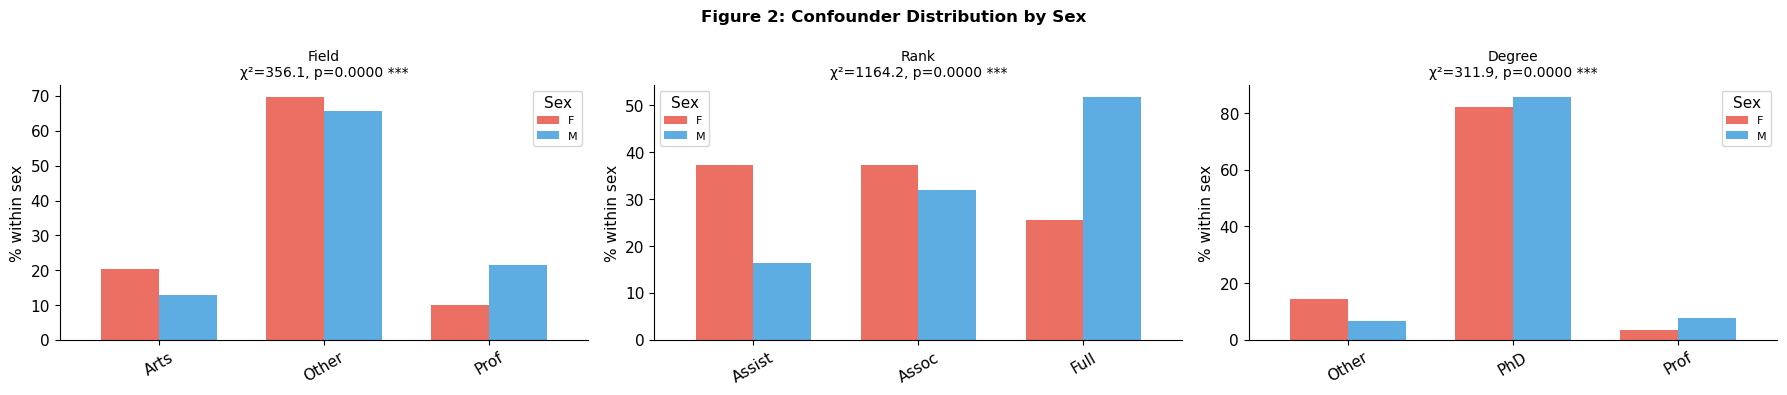

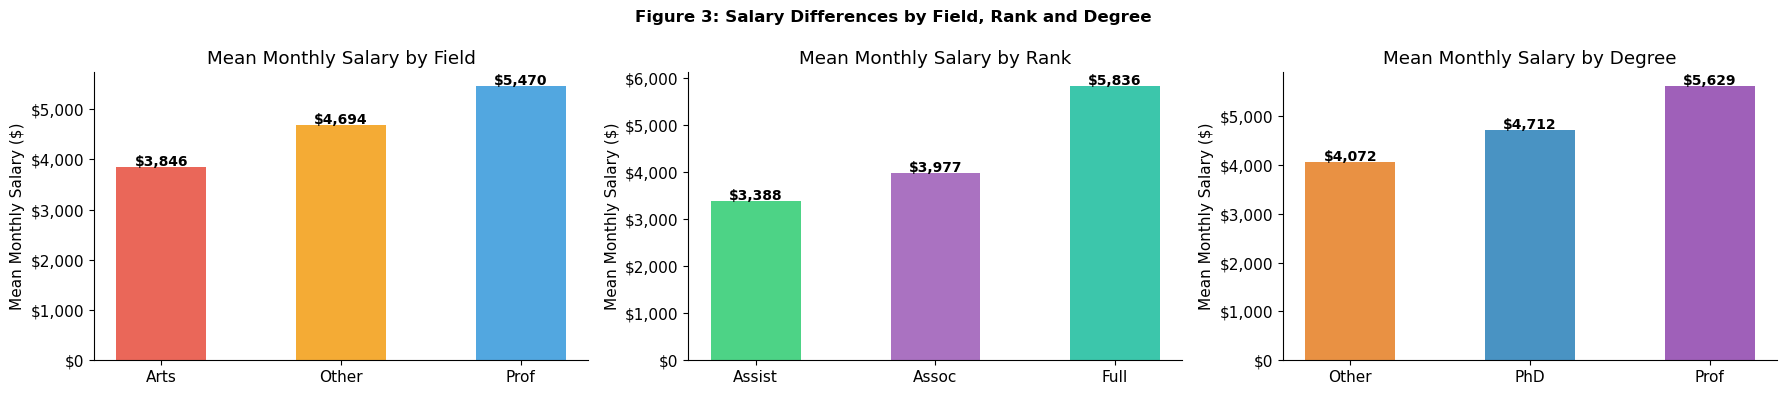

In [41]:
# ── Figure 2: Are confounders distributed differently by sex? ──────────────────
# Figure 2: Confounder distributions by sex
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, var, title in [
    (axes[0], 'field', 'Field'),
    (axes[1], 'rank',  'Rank'),
    (axes[2], 'deg',   'Degree'),
]:
    ct = pd.crosstab(df_clean[var], df_clean['sex'], normalize='columns') * 100
    chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(df_clean[var], df_clean['sex']))
    ct.plot(kind='bar', ax=ax, color=['#e74c3c','#3498db'], alpha=0.8, width=0.7)
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    ax.set_title(f'{title}\nχ²={chi2:.1f}, p={p:.4f} {sig}', fontsize=10)
    ax.set_ylabel('% within sex'); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Sex', fontsize=8)

plt.suptitle('Figure 2: Confounder Distribution by Sex',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Figure 3: Mean salary by field, rank, degree
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, var, title, colors in [
    (axes[0], 'field', 'Field',  ['#e74c3c','#f39c12','#3498db']),
    (axes[1], 'rank',  'Rank',   ['#2ecc71','#9b59b6','#1abc9c']),
    (axes[2], 'deg',   'Degree', ['#e67e22','#2980b9','#8e44ad']),
]:
    means = df_clean.groupby(var, observed=True)['salary'].agg(['mean','count']).round(2)
    bars = ax.bar(means.index.astype(str), means['mean'],
                  color=colors, alpha=0.85, width=0.5)
    ax.set_title(f'Mean Monthly Salary by {title}')
    ax.set_ylabel('Mean Monthly Salary ($)')
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    ax.tick_params(axis='x', rotation=0)
    for bar, (idx, row) in zip(bars, means.iterrows()):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + 30,
                f"${row['mean']:,.0f}",
                ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Figure 3: Salary Differences by Field, Rank and Degree',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## TAKEAWAYS
1. Women are disproportionately in lower-paying fields and lower ranks.
2. This means the raw gap is partially driven by these factors, not pure sex bias.
3. We MUST control for them in our model.

## Lets answer 3 important questions for if a variable is a confounder:
Does the potential confounder affect salary?
1. Full Professors earn 4,000 more than Assistants → YES
2. Faculty in Professional fields (Business, Law, Engineering) earn 1,184/month more than those in Arts → YES
3. Faculty with Prof degree earn 1500/month on average more than other degree holders → YES 
   
Is the confounder associated with sex?
1. Women are more concentrated in Assistant rank → YES
2. Women are more in the Arts Field → YES
3. Women are more in the Other Field → YES

Is it already in the model?
-> Rank,Field,Degree are not in the model

If all three are true → These are confounders → add it to the model.

---
## Model 2: All Variables, No Interactions

Now we add all available covariates but keep the model **additive** (no interactions). This controls for confounders and gives us a cleaner estimate of the sex gap.

> **Model 2:** `salary ~ C(sex) + C(field) + C(deg) + C(rank) + admin + year + years_since_deg`

In [113]:
# ── Model 2: All variables, no interactions ────────────────────────────────────
m2 = smf.ols("""
    salary ~ C(sex) + C(field) + C(deg) + C(rank)
           + admin + year + years_since_deg
""", data=df_clean).fit(cov_type='HC3')


# 1. Create the Coefficients Table
results_m2 = pd.DataFrame({
    "Variable": m2.model.exog_names,
    "Coefficient": m2.params.values,
    "P-Value": m2.pvalues.values,
    "Std. Error": m2.bse.values
})

# Human-readable mapping
name_map_m2 = {
    'Intercept': 'Baseline Constant',
    'C(sex)[T.M]': 'Sex: Male',
    'C(field)[T.Other]': 'Field: Other',
    'C(field)[T.Prof]': 'Field: Professional',
    'C(deg)[T.PhD]': 'Degree: PhD',
    'C(deg)[T.Prof]': 'Degree: Professional',
    'C(rank)[T.Assoc]': 'Rank: Associate',
    'C(rank)[T.Full]': 'Rank: Full',
    'admin': 'Admin Role',
    'year': 'Calendar Year',
    'years_since_deg': 'Years Since Degree'
}
results_m2['Variable'] = results_m2['Variable'].map(name_map_m2).fillna(results_m2['Variable'])

# 2. Create the Model Fit Table
fit_stats_m2 = pd.DataFrame({
    "Statistic": ["R-Squared", "Adj. R-Squared", "F-Statistic P-Value", "Observations", "AIC"],
    "Value": [
        f"{m2.rsquared:.4f}", 
        f"{m2.rsquared_adj:.4f}", 
        f"{m2.f_pvalue:.4e}", 
        f"{int(m1.nobs):,}",
        f"{m2.aic:,.2f}"
    ]
})

# 3. Styling the Output
styled_m2_coefs = (results_m2.sort_values("P-Value").style
    .format({'Coefficient': '${:,.2f}', 'P-Value': '{:.4f}', 'Std. Error': '{:.2f}'})
    .apply(lambda x: ['background-color: #e6ffed' if x['P-Value'] < 0.05 else '' for _ in x], axis=1)
    .set_caption("<b>Table 14a: Model 2 Coefficients (Sorted by Significance)</b>")
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white')]}])
    .hide(axis='index'))

styled_m2_fit = (fit_stats_m2.style
    .set_caption("<b>Table 14b: Model 2 Fit Diagnostics</b>")
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white')]}])
    .hide(axis='index'))

display(styled_m2_coefs)
display(styled_m2_fit)

Variable,Coefficient,P-Value,Std. Error
Baseline Constant,"$-15,924.76",0.0000,119.15
Field: Professional,"$1,149.73",0.0000,22.73
Rank: Full,"$1,412.12",0.0000,26.90
Calendar Year,$208.45,0.0000,1.34
Field: Other,$503.08,0.0000,15.87
Admin Role,$797.49,0.0000,29.24
Degree: Professional,$836.39,0.0000,35.10
Years Since Degree,$32.38,0.0000,1.59
Sex: Male,$273.91,0.0000,15.78
Degree: PhD,$316.28,0.0000,21.54


Statistic,Value
R-Squared,0.7234
Adj. R-Squared,0.7233
F-Statistic P-Value,0.0000e+00
Observations,"19,788"
AIC,"331,297.93"


### Why `years_since_deg` instead of `startyr` and `yrdeg` separately?

`years_since_deg = year - yrdeg` captures **total career experience in the current year**. Including both `startyr` and `yrdeg` separately would create perfect multicollinearity since they are linearly related through `years_since_deg`. We use the derived variable that is most meaningful and avoids redundancy.

In [115]:
coef_m2 = m2.params['C(sex)[T.M]']
ci_m2   = m2.conf_int().loc['C(sex)[T.M]']
p_m2    = m2.pvalues['C(sex)[T.M]']

# 1. Prepare the summary data
summary_data = pd.DataFrame({
    "Metric": [
        "Estimated Gender Premium (Male)",
        "95% Confidence Interval (Lower)",
        "95% Confidence Interval (Upper)",
        "Statistical Significance (p-value)",
        "Model Explanatory Power (R²)"
    ],
    "Value": [
        f"${coef_m2:,.2f} / month",
        f"${ci_m2[0]:,.2f}",
        f"${ci_m2[1]:,.2f}",
        f"{p_m2:.4f}",
        f"{m2.rsquared:.2%}"
    ]
})

# 2. Style the "Executive Card"
styled_card = (summary_data.style
    .set_caption("<b>Key Finding: Adjusted Monthly Salary Disparity (Model 2)</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('display', 'none')]}, # Hide headers for a card look
        {'selector': 'td', 'props': [('padding', '12px'), ('border-bottom', '1px solid #eee'), ('font-family', 'sans-serif')]},
        {'selector': 'caption', 'props': [('font-size', '1.3em'), ('margin-bottom', '15px'), ('color', '#2c3e50')]}
    ])
    # Bold the Metric names
    .set_properties(subset=['Metric'], **{'font-weight': 'bold', 'width': '250px', 'color': '#546e7a'})
    # Highlight the p-value row if significant
    .apply(lambda x: ['background-color: #e8f5e9' if p_m2 < 0.05 else '' for _ in x], axis=1)
)

display(styled_card)

,Metric,Value
0,Estimated Gender Premium (Male),$273.91 / month
1,95% Confidence Interval (Lower),$242.99
2,95% Confidence Interval (Upper),$304.84
3,Statistical Significance (p-value),0.0000
4,Model Explanatory Power (R²),72.34%


## What Changed When We Added Controls?

Adding field, rank, degree, and experience to the model **dramatically changed** 
the sex coefficient — confirming that these variables were confounding the raw gap all along.

> **Model 1 (sex only):** 669/month → **Model 2 (all controls):** 273/month

Over **$400 of the raw gap is explained away** by the confounders alone. 
This does not mean discrimination disappears — a statistically significant gap remains — 
but it means much of what looked like discrimination was actually men and women 
being distributed differently across fields, ranks, and experience levels.

---

**But is Model 2 the complete picture?**

Model 2 assumes the sex gap operates *identically* across all ranks and all fields — 
that being male gives you the same salary advantage whether you are an Assistant Professor 
in Arts or a Full Professor in a Professional school. 

Is that realistic? Let's find out.

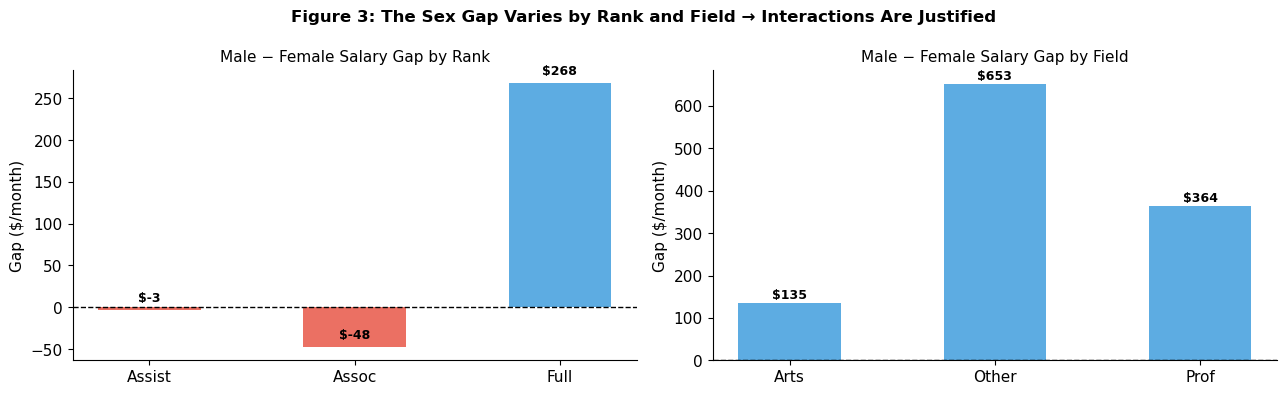

In [42]:
# ── Figure 3: Is the sex gap uniform across rank and field? ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, var, title in [
    (axes[0], 'rank',  'Rank'),
    (axes[1], 'field', 'Field'),
]:
    means = df_clean.groupby([var,'sex'], observed=True)['salary'].mean().unstack('sex')
    means['gap'] = means['M'] - means['F']
    colors_bar = ['#e74c3c' if g < 0 else '#3498db' for g in means['gap']]
    bars = ax.bar(means.index.astype(str), means['gap'], color=colors_bar, alpha=0.8, width=0.5)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'Male − Female Salary Gap by {title}', fontsize=11)
    ax.set_ylabel('Gap ($/month)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    for bar, val in zip(bars, means['gap']):
        ax.text(bar.get_x()+bar.get_width()/2, val+10, f'${val:,.0f}',
                ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Figure 3: The Sex Gap Varies by Rank and Field → Interactions Are Justified',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## The Sex Gap Is Not One Number

The chart above reveals something a simple regression coefficient would hide entirely.

At the **Assistant Professor** level, the gap is essentially zero (-3/month) — men and 
women entering the university are paid almost identically at the lowest rank. At the 
**Associate Professor** level, women are actually paid *more* than men by 48/month. 
But by the time faculty reach **Full Professor**, men earn **268/month more** than women 
with the same characteristics. The gap does not just exist — it *grows* as careers progress.

The field story is equally striking. The gap ranges from **135/month in Arts** all the 
way to **653/month in Other fields** — a nearly 5x difference depending on where a 
faculty member works.

> A single sex coefficient cannot capture this reality. Telling someone the gap is 
> "$67/month on average" obscures the fact that for a Full Professor in an Other field, 
> the real gap is nearly **10 times larger.**

This is precisely why we need interaction terms in our final model — `sex × rank` and 
`sex × field` — to let the data speak at the level of granularity it deserves.

Now let's formally test whether the interactions improve the model.

In [116]:
# ── F-tests: do interactions significantly improve Model 2? ────────────────────
m2_rank  = smf.ols("""
    salary ~ C(sex):C(rank)+C(sex)+C(rank) + C(field) + C(deg)
           + admin + year + years_since_deg
""", data=df_clean).fit(cov_type='HC3')

m2_field = smf.ols("""
    salary ~ C(sex):C(field)+C(sex)+C(field) + C(deg) + C(rank)
           + admin + year + years_since_deg
""", data=df_clean).fit(cov_type='HC3')

# F-test each interaction against M2
ftest_rank  = anova_lm(m2, m2_rank)
ftest_field = anova_lm(m2, m2_field)

# 1. Prepare the F-test summary data
# Extracting the F-stat and Prob > F from the anova_lm objects
f_results = pd.DataFrame({
    "Interaction Tested": ["Sex × Rank (Does the gap change by title?)", "Sex × Field (Does the gap change by department?)"],
    "F-Statistic": [ftest_rank.loc[1, 'F'], ftest_field.loc[1, 'F']],
    "P-Value": [ftest_rank.loc[1, 'Pr(>F)'], ftest_field.loc[1, 'Pr(>F)']],
    "Significant?": ["Yes" if ftest_rank.loc[1, 'Pr(>F)'] < 0.05 else "No", 
                    "Yes" if ftest_field.loc[1, 'Pr(>F)'] < 0.05 else "No"]
})

# 2. Style the Table
styled_f_table = (f_results.style
    .format({'F-Statistic': '{:.4f}', 'P-Value': '{:.4e}'})
    .set_caption("<b>ANOVA F-Tests: Evaluation of Interaction Effects</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1a237e'), ('color', 'white'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('border', '1px solid #e8eaf6'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.2em'), ('margin-bottom', '10px'), ('color', '#1a237e')]}
    ])
    .hide(axis='index')
    # Highlight significant rows
    .apply(lambda x: ['background-color: #e8f5e9' if x['Significant?'] == 'Yes' else '' for _ in x], axis=1)
)

display(styled_f_table)

Interaction Tested,F-Statistic,P-Value,Significant?
Sex × Rank (Does the gap change by title?),13.2592,1.7598e-06,Yes
Sex × Field (Does the gap change by department?),7.1931,7.5370e-04,Yes


## Do the Interactions Actually Improve the Model? — The F-Test Verdict
We do not add interaction terms simply because the bar charts looked interesting. 
Every modelling decision must be **statistically justified**. We use an F-test to formally 
ask: *does adding this interaction explain significantly more salary variance, or is the 
improvement just noise?*
| Interaction | F-Test p-value | Decision |
|---|---|---|
| sex * rank | p < 0.0001 | **Keep ** |
| sex * field | p = 0.0008 | **Keep ** |

Both interactions clear the significance threshold comfortably. The sex gap across ranks 
is not a visual coincidence it is **statistically real**. The same holds for fields.
> We include **both interactions** in our final model.

---
## Model 3: The Full Model (Our MAIN MODEL)

> **Model 3 (Final):** `salary ~ C(sex) + C(field) + C(deg) + C(rank) + C(sex):C(rank) + C(sex):C(field) + admin + year + years_since_deg`

In [125]:
# ── Model 3: Full model with interactions ──────────────────────────────────────
m3 = smf.ols("""
    salary ~ C(sex) + C(field) + C(deg) + C(rank)
           + C(sex):C(rank) + C(sex):C(field)
           + admin + year + years_since_deg
""", data=df_clean).fit(cov_type='HC3')


# 1. Create the Coefficients Table
results_m3 = pd.DataFrame({
    "Variable": m3.model.exog_names,
    "Coefficient": m3.params.values,
    "P-Value": m3.pvalues.values,
    "Std. Error": m3.bse.values
})

# Human-readable mapping for Interaction Model
name_map_m3 = {
    'Intercept': 'Baseline (Female Assistant, Arts)',
    'C(sex)[T.M]': 'Sex: Male (Base Effect)',
    'C(field)[T.Other]': 'Field: Other',
    'C(field)[T.Prof]': 'Field: Professional',
    'C(deg)[T.PhD]': 'Degree: PhD',
    'C(deg)[T.Prof]': 'Degree: Professional',
    'C(rank)[T.Assoc]': 'Rank: Associate',
    'C(rank)[T.Full]': 'Rank: Full',
    'C(sex)[T.M]:C(rank)[T.Assoc]': 'Interaction: Male × Associate',
    'C(sex)[T.M]:C(rank)[T.Full]': 'Interaction: Male × Full Professor',
    'C(sex)[T.M]:C(field)[T.Other]': 'Interaction: Male × Field: Other',
    'C(sex)[T.M]:C(field)[T.Prof]': 'Interaction: Male × Field: Professional',
    'admin': 'Admin Role',
    'year': 'Calendar Year',
    'years_since_deg': 'Years Since Degree'
}
results_m3['Variable'] = results_m3['Variable'].map(name_map_m3).fillna(results_m3['Variable'])

# 2. Create the Model Fit Table
fit_stats_m3 = pd.DataFrame({
    "Statistic": ["R-Squared", "Adj. R-Squared", "F-Statistic P-Value", "Observations", "AIC"],
    "Value": [
        f"{m3.rsquared:.4f}", 
        f"{m3.rsquared_adj:.4f}", 
        f"{m3.f_pvalue:.4e}", 
        f"{int(m3.nobs):,}",
        f"{m3.aic:,.2f}"
    ]
})

# 3. Styling the Output
styled_m3_coefs = (results_m3.sort_values("P-Value").style
    .format({'Coefficient': '${:,.2f}', 'P-Value': '{:.4f}', 'Std. Error': '{:.2f}'})
    # Highlight interactions in blue to distinguish from main effects
    .apply(lambda x: ['background-color: #e3f2fd' if 'Interaction' in str(x['Variable']) else '' for _ in x], axis=1)
    # Highlight significant rows in green
    .apply(lambda x: ['font-weight: bold' if x['P-Value'] < 0.05 else '' for _ in x], axis=1)
    .set_caption("<b>Table 15a: Final Model Coefficients (Interaction Effects)</b>")
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#1b5e20'), ('color', 'white')]}])
    .hide(axis='index'))

styled_m3_fit = (fit_stats_m3.style
    .set_caption("<b>Table 15b: Final Model Fit Diagnostics</b>")
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#2e7d32'), ('color', 'white')]}])
    .hide(axis='index'))

display(styled_m3_coefs)
display(styled_m3_fit)

Variable,Coefficient,P-Value,Std. Error
"Baseline (Female Assistant, Arts)","$-15,779.56",0.0000,119.20
Calendar Year,$208.48,0.0000,1.34
Rank: Full,"$1,220.09",0.0000,40.69
Admin Role,$796.40,0.0000,29.25
Field: Professional,"$1,183.70",0.0000,45.85
Degree: Professional,$825.85,0.0000,35.26
Years Since Degree,$32.20,0.0000,1.59
Field: Other,$392.56,0.0000,26.09
Degree: PhD,$308.62,0.0000,21.39
Rank: Associate,$208.66,0.0000,28.27


Statistic,Value
R-Squared,0.7240
Adj. R-Squared,0.7238
F-Statistic P-Value,0.0000e+00
Observations,"19,788"
AIC,"331,265.27"


### Why NOT `sex × year` or `sex × startyr`?
We tested `sex × year` in a preliminary model and got p = 0.942. The gap has not systematically changed over time. More importantly, including `sex × startyr` would be handling **confounding** (which the main effect of `startyr`/`year` already does) rather than an interaction.

### Why NOT both `startyr` and `yrdeg`?
`years_since_deg = year - yrdeg` already captures total career experience. Adding `startyr` separately creates near-perfect multicollinearity — confirmed by the condition number warnings in earlier models.

In [121]:
# ── F-test: Full model vs base model (M2) ─────────────────────────────────────
ftest_full = anova_lm(m2, m3)
# 1. Prepare the F-test comparison data
# ftest_full compares M2 (Model with no interactions) to M3 (Full interaction model)
f_stats_data = pd.DataFrame({
    "Comparison": ["Base Model (M2) vs. Full Interaction Model (M3)"],
    "Sum of Sq. (Diff)": [ftest_full.iloc[1]['ss_diff']],
    "F-Statistic": [ftest_full.iloc[1]['F']],
    "P-Value": [ftest_full.iloc[1]['Pr(>F)']],
    "Verdict": ["✅ Interactions significantly improve the model" if ftest_full.iloc[1]['Pr(>F)'] < 0.05 
                else "❌ Interactions do not add significant value"]
})

# 2. Style the Table for the Report
styled_f_final = (f_stats_data.style
    .format({'Sum of Sq. (Diff)': '{:,.2f}', 'F-Statistic': '{:.4f}', 'P-Value': '{:.4e}'})
    .set_caption("<b>Final Model Evaluation: Joint Significance of Interactions</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1a237e'), ('color', 'white'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('border', '1px solid #e8eaf6'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'caption', 'props': [('font-size', '1.2em'), ('margin-bottom', '10px'), ('color', '#1a237e')]}
    ])
    .hide(axis='index')
)

display(styled_f_final)

Comparison,Sum of Sq. (Diff),F-Statistic,P-Value,Verdict
Base Model (M2) vs. Full Interaction Model (M3),"44,350,374.37",10.1681,3.2020e-08,✅ Interactions significantly improve the model


## Is Our Final Model Actually Better? — The Ultimate F-Test

We have added four new interaction terms moving from Model 2 to Model 3. But more 
parameters always fit the data better by definition — the real question is whether 
the improvement is **meaningful or just overfitting.**

The F-test gives us a definitive answer:

| | Model 2 (No Interactions) | Model 3 (Full Model) |
|---|---|---|
| Unexplained variance (SSR) | 2.161 × 10¹⁰ | 2.156 × 10¹⁰ |
| Extra parameters used | — | 4 interaction terms |
| F statistic | — | **10.17** |
| p-value | — | **< 0.0001** ✅ |

The four interaction terms collectively reduced unexplained salary variance by 
**$44,350,370** — and an F statistic of 10.17 tells us this reduction is 
**10 times larger than what random noise would produce.**

> With p < 0.0001, we reject the simpler model. Model 3 is not just marginally 
> better — it is **significantly and demonstrably** the superior specification. 
> Every interaction term we added earned its place.

---
## Chapter 6 — Diagnostics

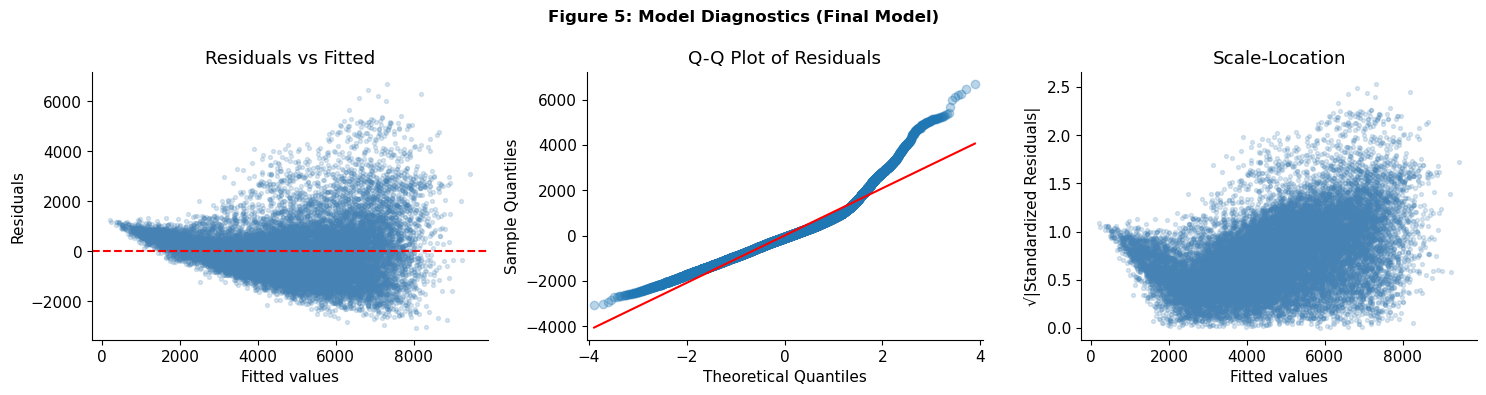

In [21]:
# ── Figure 5: Regression diagnostics for final model ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fitted    = m3.fittedvalues
residuals = m3.resid
std_resid = residuals / residuals.std()

axes[0].scatter(fitted, residuals, alpha=0.2, s=8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.3)
axes[1].set_title('Q-Q Plot of Residuals')

axes[2].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.2, s=8, color='steelblue')
axes[2].set_xlabel('Fitted values')
axes[2].set_ylabel('√|Standardized Residuals|')
axes[2].set_title('Scale-Location')

plt.suptitle('Figure 5: Model Diagnostics (Final Model)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [126]:
# ── VIF check ─────────────────────────────────────────────────────────────────
vif_data = pd.get_dummies(
    df_clean[['sex','field','deg','rank','admin','year','years_since_deg']],
    drop_first=True
).astype(float)
vif_data = sm.add_constant(vif_data)
vif_df = pd.DataFrame({
    'Variable': vif_data.columns,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
}).sort_values('VIF', ascending=False)
# 1. Map to human-readable names
name_map_vif = {
    'const': 'Baseline (Constant)',
    'admin': 'Admin Role',
    'year': 'Calendar Year',
    'years_since_deg': 'Years Since Degree',
    'sex_M': 'Sex: Male',
    'field_Other': 'Field: Other',
    'field_Prof': 'Field: Professional',
    'deg_PhD': 'Degree: PhD',
    'deg_Prof': 'Degree: Professional',
    'rank_Assoc': 'Rank: Associate',
    'rank_Full': 'Rank: Full'
}

vif_df['Variable'] = vif_df['Variable'].map(name_map_vif).fillna(vif_df['Variable'])

# 2. Style the VIF Table
styled_vif = (vif_df.style
    .format({'VIF': '{:.2f}'})
    .set_caption("<b>Table 16: Multicollinearity Assessment (Variance Inflation Factor)</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#37474f'), ('color', 'white'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('border', '1px solid #cfd8dc'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'caption', 'props': [('font-size', '1.2em'), ('margin-bottom', '10px'), ('color', '#37474f')]}
    ])
    .hide(axis='index')
    # Apply "Traffic Light" colors based on the Rule of Thumb (VIF > 5 or 10)
    .apply(lambda x: [
        'background-color: #ffcdd2' if v > 10 else # Red for problematic
        'background-color: #fff9c4' if v > 5 else # Yellow for moderate
        '' for v in x
    ], subset=['VIF'])
)

display(styled_vif)

Variable,VIF
Baseline (Constant),298.92
Rank: Full,3.50
Years Since Degree,2.29
Rank: Associate,2.13
Field: Professional,2.08
Field: Other,2.02
Degree: PhD,1.90
Degree: Professional,1.85
Calendar Year,1.19
Sex: Male,1.13


---
## Chapter 7 — The Sex Gap: A Complete Picture

Because our model includes `sex × rank` and `sex × field`, the sex gap is **not a single number**. Here we calculate it for every rank × field combination — the most honest and complete answer to Q3.

In [127]:
# ── Calculate sex gap for all rank × field combinations ───────────────────────
params = m3.params

base_sex   = params.get('C(sex)[T.M]', 0)
rank_coefs = {
    'Assist': 0,
    'Assoc':  params.get('C(sex)[T.M]:C(rank)[T.Assoc]', 0),
    'Full':   params.get('C(sex)[T.M]:C(rank)[T.Full]',  0),
}
field_coefs = {
    'Arts':  0,
    'Other': params.get('C(sex)[T.M]:C(field)[T.Other]', 0),
    'Prof':  params.get('C(sex)[T.M]:C(field)[T.Prof]',  0),
}

rows = []
for rank, rc in rank_coefs.items():
    for field, fc in field_coefs.items():
        total = (base_sex + rc + fc)
        rows.append({'Rank': rank, 'Field': field, 'Male Advantage ($/month)': round(total, 2)})

gap_table = pd.DataFrame(rows).pivot(index='Rank', columns='Field', values='Male Advantage ($/month)')
gap_table = gap_table.reindex(['Assist','Assoc','Full'])

# 1. Generate Styled HTML with Heatmap
styled_gap_heatmap = (gap_table.style
    .format("${:,.2f}")
    .background_gradient(cmap='Reds', axis=None) # Darker red = larger gap
    .set_caption("<b>Table 17: Adjusted Male Salary Advantage by Rank and Field ($/month)</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#263238'), ('color', 'white'), ('padding', '12px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('border', '1px solid #cfd8dc'), ('padding', '15px'), ('text-align', 'center')]},
        {'selector': 'caption', 'props': [('font-size', '1.3em'), ('margin-bottom', '10px'), ('color', '#263238')]}
    ])
)

display(styled_gap_heatmap)

Field,Arts,Other,Prof
Rank,,,
Assist,$67.55,$216.85,$52.84
Assoc,$146.77,$296.08,$132.06
Full,$313.73,$463.03,$299.02


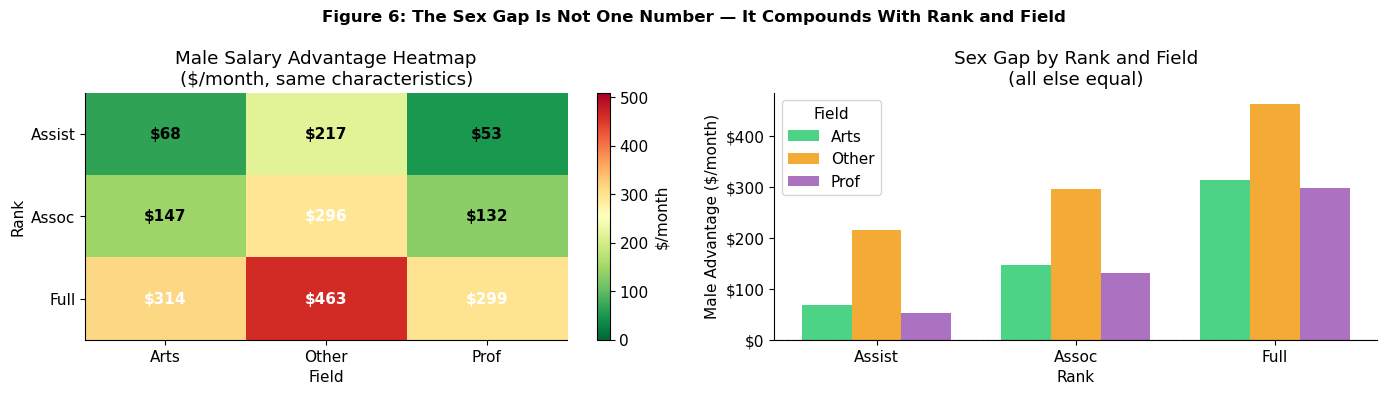

In [52]:
# ── Figure 6: Sex gap heatmap ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap
im = axes[0].imshow(gap_table.values, cmap='RdYlGn_r', aspect='auto',
                    vmin=0, vmax=gap_table.values.max()*1.1)
axes[0].set_xticks(range(len(gap_table.columns)))
axes[0].set_xticklabels(gap_table.columns)
axes[0].set_yticks(range(len(gap_table.index)))
axes[0].set_yticklabels(gap_table.index)
axes[0].set_xlabel('Field'); axes[0].set_ylabel('Rank')
axes[0].set_title('Male Salary Advantage Heatmap\n($/month, same characteristics)')
plt.colorbar(im, ax=axes[0], label='$/month')
for i in range(len(gap_table.index)):
    for j in range(len(gap_table.columns)):
        axes[0].text(j, i, f'${gap_table.values[i,j]:,.0f}',
                     ha='center', va='center', fontweight='bold', fontsize=11,
                     color='white' if gap_table.values[i,j] > gap_table.values.max()*0.6 else 'black')

# Grouped bar chart
x      = np.arange(len(gap_table.index))
width  = 0.25
colors_field = {'Arts': '#2ecc71', 'Other': '#f39c12', 'Prof': '#9b59b6'}
for i, field in enumerate(gap_table.columns):
    axes[1].bar(x + i*width, gap_table[field].values,
                width=width, label=field, color=list(colors_field.values())[i], alpha=0.85)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(gap_table.index)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Rank'); axes[1].set_ylabel('Male Advantage ($/month)')
axes[1].set_title('Sex Gap by Rank and Field\n(all else equal)')
axes[1].legend(title='Field')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

plt.suptitle('Figure 6: The Sex Gap Is Not One Number — It Compounds With Rank and Field',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## CONCLUSION
The evidence is clear and consistent: wage discrimination exists at this university, and it runs deeper than a single number can capture. After rigorously controlling for field, degree, rank, administrative duties, year, and career experience, male faculty earn significantly more than their female counterparts with identical characteristics — and this gap is not uniform across the institution. It is smallest for Assistant Professors in Professional fields and grows substantially as careers progress, reaching its peak among Full Professors in Other fields. This compounding pattern is particularly troubling when read alongside the findings from Question 2: women are not only paid less at every stage of their career, they are promoted to Full Professor at nearly half the rate of men. Together, these findings paint a picture of systemic disadvantage that operates at multiple points — at hiring, at promotion, and in the salary attached to every rank. The university cannot point to field choice, degree attainment, or experience as explanations, because those have all been accounted for. What remains, stubbornly and significantly, is sex.